In [1]:
%load_ext autoreload

%autoreload 2

In [2]:
import pandas as pd
from datetime import datetime, timedelta
from difflib import SequenceMatcher
import matplotlib.pyplot as plt
import seaborn as sns   
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
import os
from pathlib import Path
import seaborn as sns
import numpy as np
from lifelines.utils import to_long_format
from lifelines.utils import add_covariate_to_timeline
from lifelines import CoxTimeVaryingFitter
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import ks_2samp
from scipy import stats
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mtick
from lifelines import KaplanMeierFitter
from lifelines.statistics import pairwise_logrank_test
from lifelines.plotting import add_at_risk_counts
import warnings
from preproces_prod4_2025_update import *
from scipy.stats import norm
import gspread
from oauth2client.service_account import ServiceAccountCredentials
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")


pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

path_actual = Path.cwd()
path_data = path_actual.parent / 'Data'

EL SIGUIENTE ARCHIVO ES EL VALOR AGREGADO DEL V_2 SOBRE EL V_1 (v_2 es v_1 "ordenado" y v_3 es el conjunto diferencia de sacarle al v_2 lo que ya esta en v_1)

In [ ]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr
df_f_any, df_f_LRTI, df_f_vrs_25, df_f_upc_25 = filtros_IH_new(df_pf_2025,cohort='2025')
df_f_any, df_f_LRTI, df_f_vrs_24, df_f_upc_24 = filtros_IH_new(df_pf_2025,cohort='2024')
df_f_any, df_f_LRTI, df_f_vrs_both, df_f_upc_both = filtros_IH_new(df_pf_2025,cohort='both')

In [ ]:
df_pf_2025 = pre_filtred(df_name='COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv',lrti_name='LRTI_Flag')#NAC_RNI_EGRESOS_ENTREGA_ISCI_20_12_2024_encr
_, _, df_f_vrs_25_mz_sep, _ = filtros_IH_new(df_pf_2025,
                                             cohort='2025',
                                             eliminar_inmunes_pre_season=False, 
                                             T_inicial = pd.to_datetime('2025-03-01'),
                                             fecha_dt = pd.to_datetime('2025-09-30'),
                                             duracion_dias_nirse=180)
_, _, df_f_vrs_24, _ = filtros_IH_new(df_pf_2025,
                                             cohort='2024',
                                             eliminar_inmunes_pre_season=False, 
                                             T_inicial = pd.to_datetime('2024-04-01'),
                                             fecha_dt = pd.to_datetime('2024-09-30'),
                                             duracion_dias_nirse=180)

### Efectividad inmunización 2025:
- marzo-sep con fin inmune 180.
- marzo-sep sin fin inmune.
- abril-sep sin fin inmune.
- octubre-sep, inicio_cox: 1 octubre.
- marzo-sep con fin inmune 150, añadiendo a los inmunes en octubre.

NUEVO SUPUESTO (para no olvidar): WAWAS NACIDAS ANTES DEL FIN DE TEMPORADA (PIENSE EN AGOSTO O SEPTIEMBRE) Y QUE FUERON VACUNADAS A POSTERIORI SON ELIMINADAS DEL ANÁLISIS. MOTIVO: NO ES JUSTO DECIR QUE SON IGUALES QUE AQUELLOS QUE NO SE INMUNIZAN, PUES SI LO HACEN :)

##### marzo-sep con fin_inmune = 180

In [10]:
df_cox_vrs_mrz_sep_180, _, df_f_vrs_mrz_sep_180, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                           40,
                                                           group_age=False,
                                                           weeks_inm=False,
                                                           fin_inmune=True,
                                                           cohort='2025',
                                                           T_inicial = pd.to_datetime('2025-03-01'),
                                                           fecha_dt = pd.to_datetime('2025-09-30'),
                                                           duracion_dias_nirse=180, # este parámetro no tiene relevancia si fin_inmune=False
                                                           eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [13]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_mrz_sep_180.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.029504,0.642816,0.102063,-1.229544,-0.829464,0.563717,0.707574,0.0
sexo,0.517227,-0.677370,0.055015,0.409400,0.625055,-0.868348,-0.505914,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


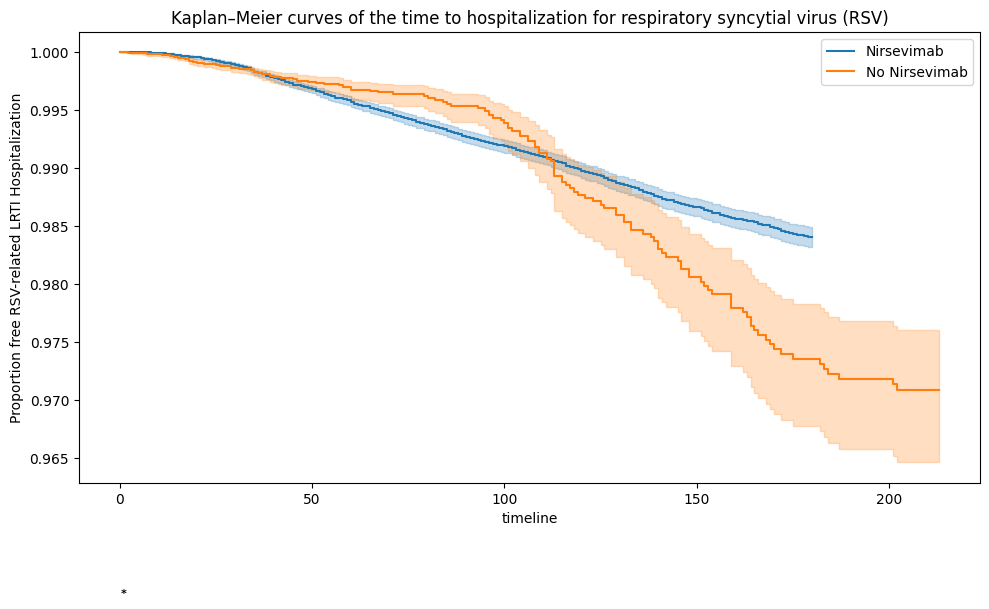

In [16]:
df_mayer_vrs_agg_mz_sep_180, df_mayer_vrs_mz_sep_180 = plot_extended_kaplan_meier(df_cox_vrs_mrz_sep_180)

##### marzo-sep sin fin_inmune

In [17]:
df_cox_vrs_mrz_sep_sinfin, _, df_f_vrs_mrz_sep_sinfin, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                           40,
                                                           group_age=False,
                                                           weeks_inm=False,
                                                           fin_inmune=False,
                                                           cohort='2025',
                                                           T_inicial = pd.to_datetime('2025-03-01'),
                                                           fecha_dt = pd.to_datetime('2025-09-30'),
                                                           duracion_dias_nirse=180, # este parámetro no tiene relevancia si fin_inmune=False
                                                           eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [18]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_mrz_sep_sinfin.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.083192,0.661487,0.104933,-1.288857,-0.877527,0.584190,0.724414,0.0
sexo,0.517620,-0.678029,0.055005,0.409812,0.625428,-0.869047,-0.506534,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


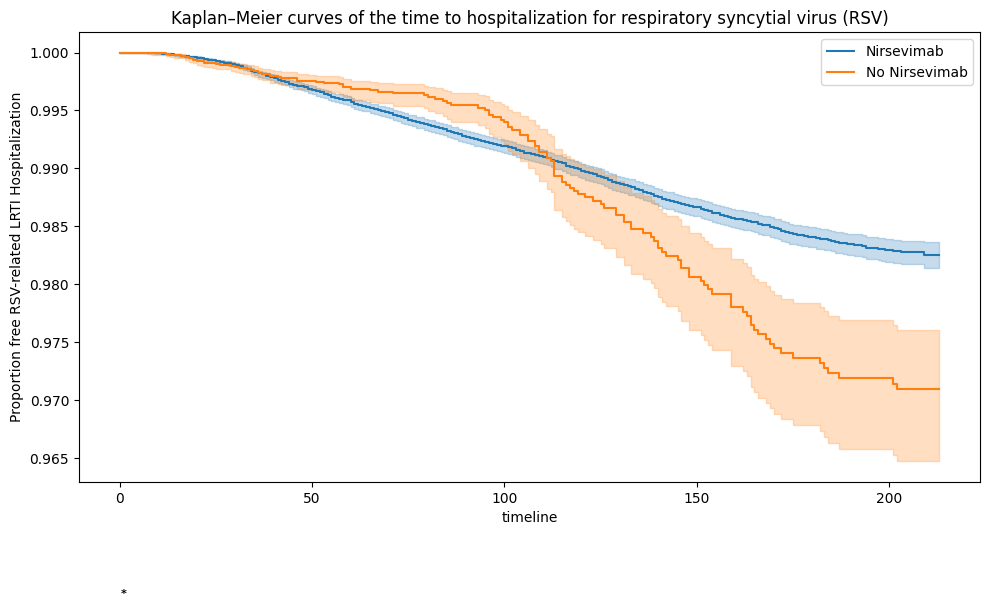

In [19]:
df_mayer_vrs_agg_mz_sep, df_mayer_vrs_mz_sep = plot_extended_kaplan_meier(df_cox_vrs_mrz_sep_sinfin)

##### abril-sep sin fin inmune.

In [20]:
df_cox_vrs_abril, _, df_f_vrs_abril, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                           40,
                                                           group_age=False,
                                                           weeks_inm=False,
                                                           fin_inmune=False,
                                                           cohort='2025',
                                                           T_inicial = pd.to_datetime('2025-04-01'),
                                                           fecha_dt = pd.to_datetime('2025-09-30'),
                                                           duracion_dias_nirse=180, # este parámetro no tiene relevancia si fin_inmune=False
                                                           eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

In [21]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_abril.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.111458,0.670921,0.106157,-1.319522,-0.903394,0.594808,0.732737,0.0
sexo,0.515483,-0.674447,0.055664,0.406384,0.624582,-0.867466,-0.501378,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


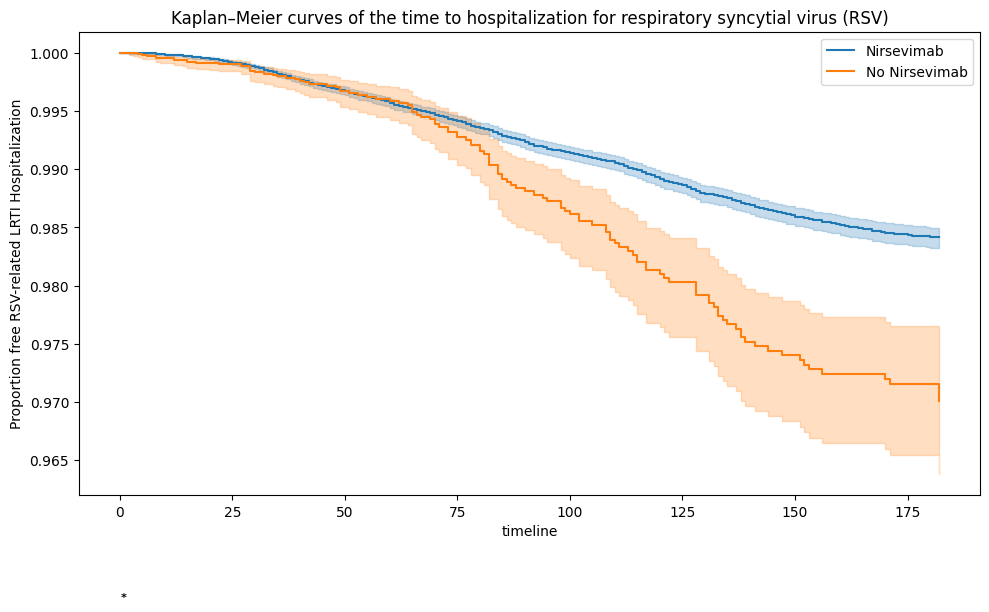

In [22]:
df_mayer_vrs_agg_abril, df_mayer_vrs_abril = plot_extended_kaplan_meier(df_cox_vrs_abril)

##### octubre-sep, inicio_cox: 1 octubre.

In [29]:
df_cox_vrs_oct_180, _, df_f_vrs_oct_180, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                           40,
                                                           group_age=False,
                                                           weeks_inm=False,
                                                           fin_inmune=True,
                                                           cohort='2025',
                                                           T_inicial = pd.to_datetime('2024-01-10'),
                                                           fecha_dt = pd.to_datetime('2025-09-30'),
                                                           duracion_dias_nirse=180,
                                                           eliminar_inmunes_pre_season=False)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.979515,0.624507,0.097336,-1.170291,-0.788739,0.545583,0.689723,0.0
sexo,0.543198,-0.721504,0.051644,0.441979,0.644418,-0.904879,-0.555782,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


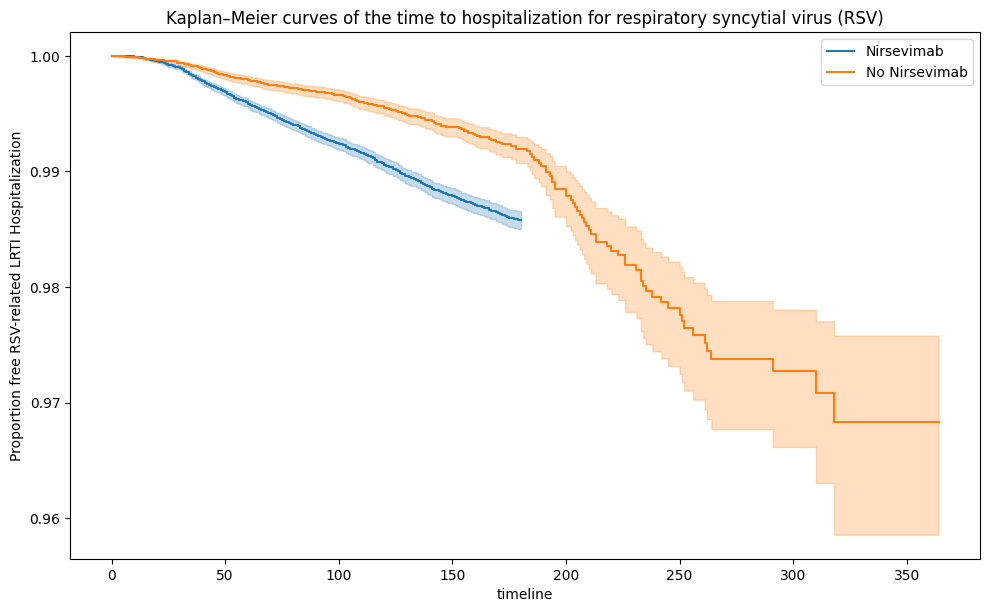

In [30]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_oct_180.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_abril, df_mayer_vrs_abril = plot_extended_kaplan_meier(df_cox_vrs_oct_180)

##### marzo-sep con fin inmune 150, añadiendo a los inmunes en octubre.

In [25]:
df_cox_vrs_mrz_sep_150_no_eli, _, df_f_vrs_mrz_sep_150_no_eli, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                                                    40,
                                                                                    group_age=False,
                                                                                    weeks_inm=False,
                                                                                    fin_inmune=True,
                                                                                    cohort='2025',
                                                                                    T_inicial = pd.to_datetime('2025-03-01'),
                                                                                    fecha_dt = pd.to_datetime('2025-09-30'),
                                                                                    duracion_dias_nirse=150, 
                                                                                    eliminar_inmunes_pre_season=False)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1018
ruts perdidos por filtro semanas y peso:  601
Droped intersex: 6
Datos perdidos por edad madre atípica: 270
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-0.915308,0.599607,0.097797,-1.106986,-0.723629,0.515011,0.669446,0.0
sexo,0.533428,-0.704766,0.053207,0.429145,0.637711,-0.892145,-0.535943,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


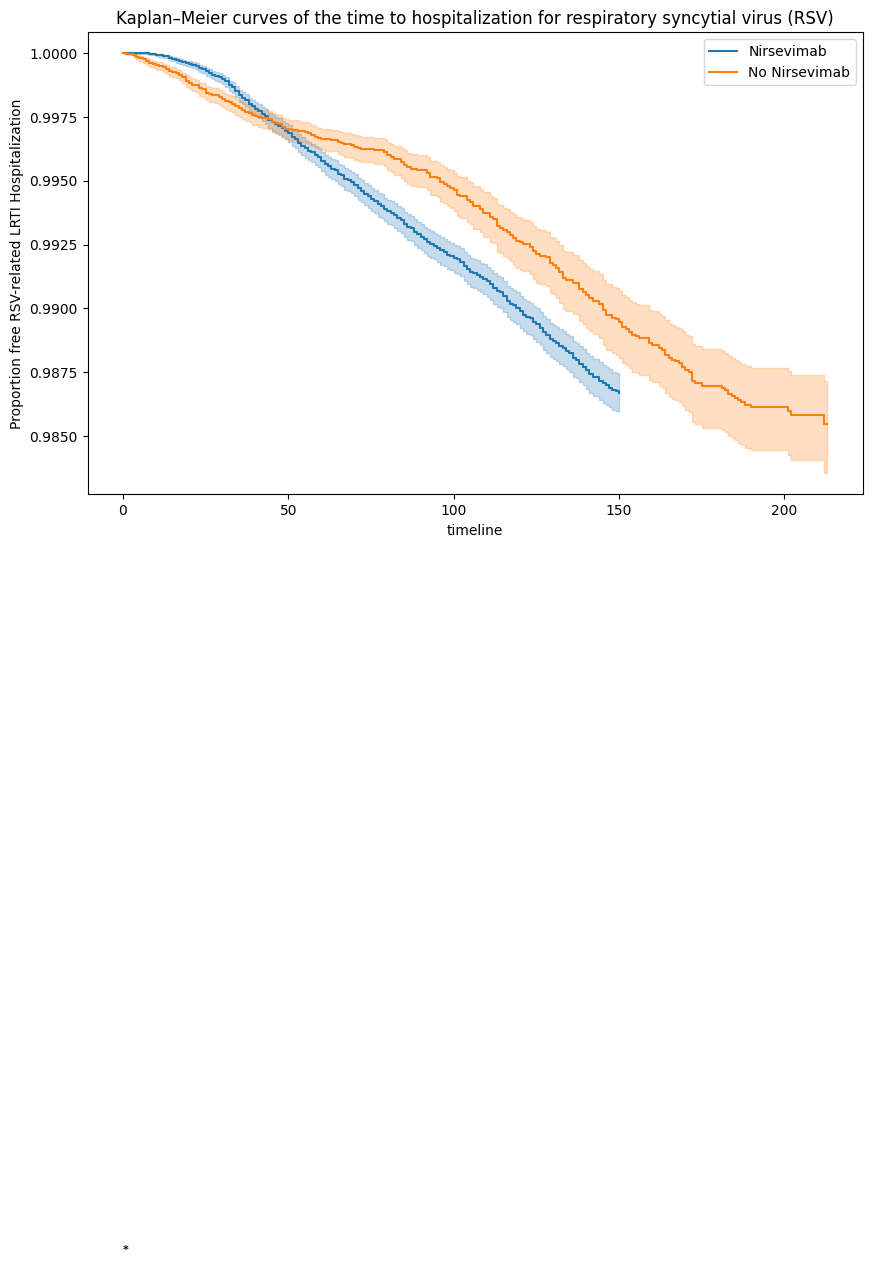

In [26]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_mrz_sep_150_no_eli.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_abril, df_mayer_vrs_abril = plot_extended_kaplan_meier(df_cox_vrs_mrz_sep_150_no_eli)

##### marzo-agosto sin fin

In [97]:
df_cox_vrs_mrz_ag, _, df_f_vrs_mrz_ag, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2025',
                                                        T_inicial = pd.to_datetime('2025-03-01'),
                                                        fecha_dt = pd.to_datetime('2025-08-31'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  962
ruts perdidos por filtro semanas y peso:  540
Droped intersex: 5
Datos perdidos por edad madre atípica: 247
Datos perdidos por fecha ingreso menor a fecha nacimiento: 12
vrs en los primeros 7 dias de 

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.117552,0.672921,0.114999,-1.342947,-0.892158,0.590229,0.738925,0.0
sexo,0.519326,-0.680894,0.061173,0.399428,0.639224,-0.895009,-0.490972,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


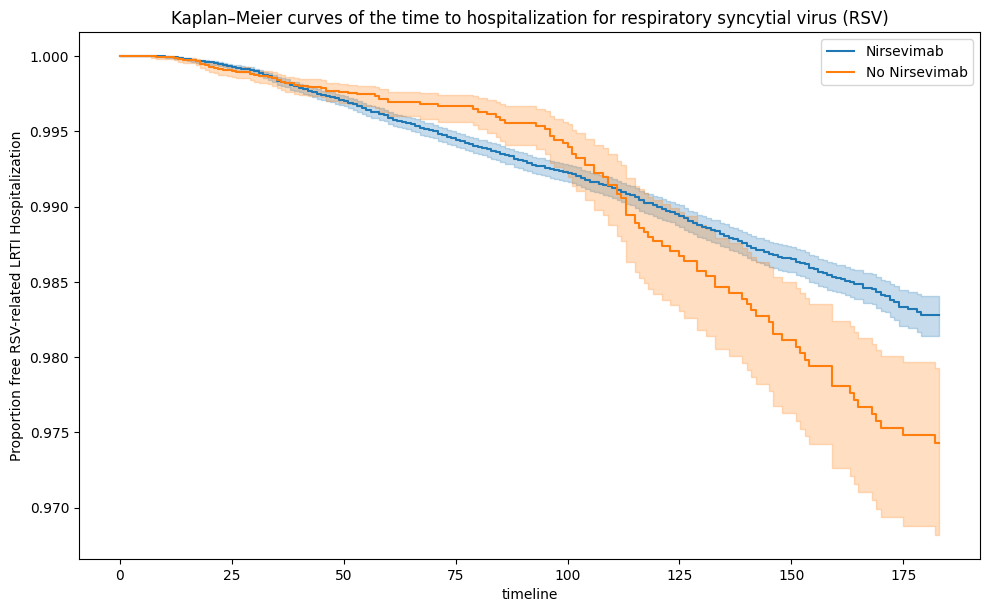

In [200]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_mrz_ag.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_mz_ag, df_mayer_vrs_mz_ag = plot_extended_kaplan_meier(df_cox_vrs_mrz_ag)

#### matching

In [201]:
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_mrz_ag.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:2",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))



1:2 ['1', '2']
here aaa
Total cases = 3085, Total controls = 111976
Total cases matched is : 2996, Total control matched is : 5992
ratio: 1:2
No matched : 89
Iteration 1: norm_delta = 7.42e-01, step_size = 0.9500, log_lik = -192.54483, newton_decrement = 4.25e+01, seconds_since_start = 2.2
Iteration 2: norm_delta = 3.17e-02, step_size = 0.9500, log_lik = -151.50853, newton_decrement = 6.75e-02, seconds_since_start = 4.5
Iteration 3: norm_delta = 2.05e-03, step_size = 0.9500, log_lik = -151.44063, newton_decrement = 2.74e-04, seconds_since_start = 6.7
Iteration 4: norm_delta = 1.10e-04, step_size = 1.0000, log_lik = -151.44036, newton_decrement = 7.09e-07, seconds_since_start = 8.9
Iteration 5: norm_delta = 5.38e-09, step_size = 1.0000, log_lik = -151.44036, newton_decrement = 1.71e-15, seconds_since_start = 11.2
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.57196,0.792362,0.186673,-1.937832,-1.206089,0.700634,0.855984,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


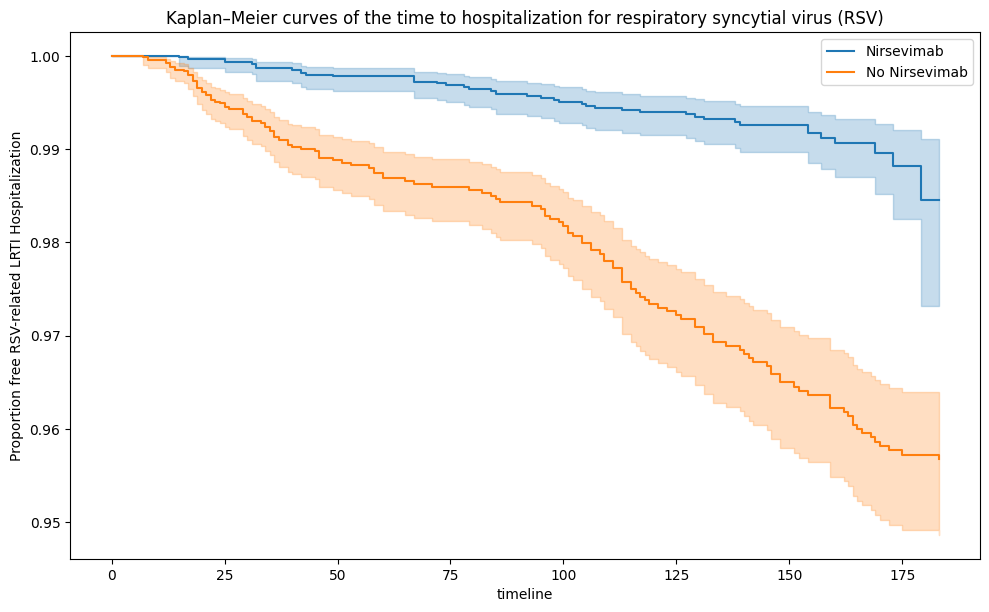

In [39]:
df_mayer_vrs_match, df_mayer_vrs_match = plot_extended_kaplan_meier(df_tv_matched)

FULL ANALISIS MATCHING ABAJO

In [167]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# ---------------------------
# Helpers básicos
# ---------------------------
ID = "RUN"
START = "start"
STOP = "stop"
EVENT = "event_vrs"
IMM_TV = "inmunizado"   # time-varying 0/1
MATCH_GROUP = "Group"   # solo en df_tv_matched

def make_baseline(df_tv, id_col=ID, start_col=START, imm_col=IMM_TV, keep_cols=None):
    """
    Devuelve 1 fila por RUN:
    - covariables basales: primera fila (mínimo start)
    - ever_imm: max(inmunizado) por RUN
    """
    df_tv = df_tv.copy()
    df_tv = df_tv.sort_values([id_col, start_col])

    if keep_cols is None:
        keep_cols = [c for c in df_tv.columns if c not in [start_col, STOP, EVENT]]  # por defecto casi todo

    base = (
        df_tv.groupby(id_col, as_index=False)
             .first()[[id_col] + [c for c in keep_cols if c != id_col]]
    )

    ever = df_tv.groupby(id_col)[imm_col].max().rename("ever_imm").reset_index()
    base = base.merge(ever, on=id_col, how="left").fillna({"ever_imm": 0})
    base["ever_imm"] = base["ever_imm"].astype(int)
    return base

# ---------------------------
# Decide covariables basales principales
# (ajústalas según tus columnas)
# ---------------------------
candidate_covs = [
    "sexo", "region", "Macrozona2", "PREVI", "SEMANAS", "mes_nac_name",
    "is_rural", "prematuro", "muy_prematuro", "prematuro_extremo", "prematuro_moderado",
    "group_age", "categori_macro", "categoric_regions", "percent_poor_multidim", "percent_poor", "percent_rural"
]

# Filtramos solo las que existen en tu df
base_covs_pre = [c for c in candidate_covs if c in df_cox_vrs_mrz_ag.columns]
base_covs_post = [c for c in candidate_covs if c in df_tv_matched.columns]

print("Covariables basales (pre):", base_covs_pre)
print("Covariables basales (post):", base_covs_post)

# Baseline pre y post
df_base_pre = make_baseline(df_cox_vrs_mrz_ag, keep_cols=[ID] + base_covs_pre)
df_base_post = make_baseline(df_tv_matched, keep_cols=[ID] + base_covs_post)

print(df_base_pre.shape, df_base_post.shape)

Covariables basales (pre): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'prematuro', 'muy_prematuro', 'prematuro_extremo', 'prematuro_moderado', 'categori_macro', 'percent_poor_multidim', 'percent_poor']
Covariables basales (post): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'prematuro', 'muy_prematuro', 'prematuro_extremo', 'prematuro_moderado', 'categori_macro', 'percent_poor_multidim', 'percent_poor']
(115061, 16) (8988, 16)


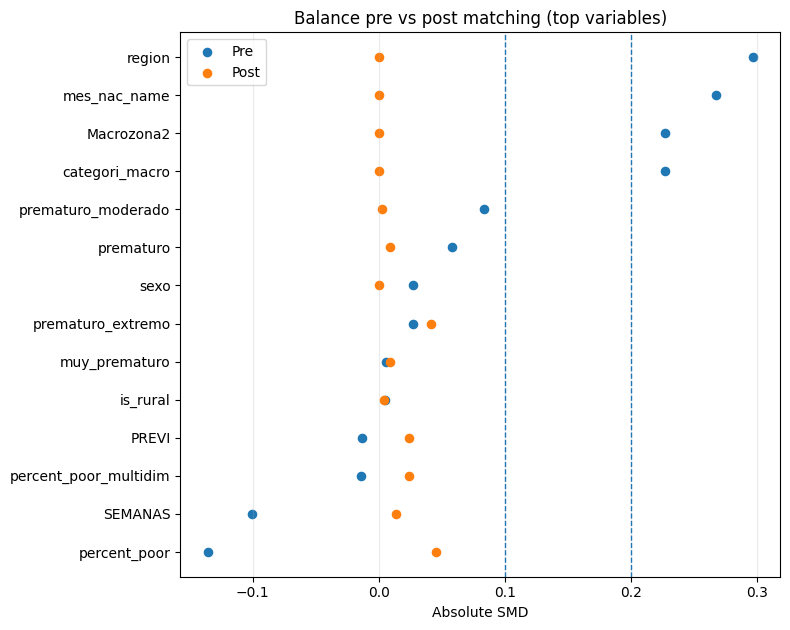

In [168]:
def smd_numeric(x_t, x_c):
    x_t = pd.to_numeric(x_t, errors="coerce")
    x_c = pd.to_numeric(x_c, errors="coerce")
    mt, mc = x_t.mean(), x_c.mean()
    vt, vc = x_t.var(ddof=1), x_c.var(ddof=1)
    sp = np.sqrt((vt + vc) / 2)
    if sp == 0 or np.isnan(sp):
        return np.nan
    return (mt - mc) / sp

def smd_binary(p_t, p_c):
    p_pool = (p_t + p_c) / 2
    denom = np.sqrt(p_pool * (1 - p_pool))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (p_t - p_c) / denom

def compute_smd_table(df_base, covs, treat_col="ever_imm"):
    """
    Devuelve tabla SMD por covariable.
    - numéricas: SMD estándar
    - categóricas: max SMD entre niveles
    """
    out = []
    treated = df_base[df_base[treat_col] == 1]
    control = df_base[df_base[treat_col] == 0]

    for col in covs:
        s = df_base[col]
        # Heurística simple: si es numérica y tiene muchos valores -> numérica; si no, categórica
        is_num = pd.api.types.is_numeric_dtype(s)
        nun = s.nunique(dropna=True)

        if is_num and nun > 5:
            smd = smd_numeric(treated[col], control[col])
            out.append({"variable": col, "type": "numeric", "SMD": smd})
        else:
            # tratar como categórica (incluye binarias)
            levels = pd.Series(pd.concat([treated[col], control[col]], axis=0).dropna().unique()).tolist()
            if len(levels) == 0:
                out.append({"variable": col, "type": "categorical", "SMD": np.nan})
                continue

            smds = []
            for lv in levels:
                pt = (treated[col] == lv).mean()
                pc = (control[col] == lv).mean()
                smds.append(abs(smd_binary(pt, pc)))
            out.append({"variable": col, "type": "categorical", "SMD": np.nanmax(smds)})

    tab = pd.DataFrame(out).sort_values("SMD", ascending=False)
    return tab

smd_pre = compute_smd_table(df_base_pre, base_covs_pre)
smd_post = compute_smd_table(df_base_post, base_covs_post)

# Combinar en una tabla bonita
smd = (smd_pre.rename(columns={"SMD":"SMD_pre"})
              .merge(smd_post.rename(columns={"SMD":"SMD_post"})[["variable","SMD_post"]],
                     on="variable", how="outer")
              .sort_values(["SMD_pre","SMD_post"], ascending=False))

# Plot "Love plot" simple
def love_plot(smd_df, top=20):
    d = smd_df.copy().sort_values("SMD_pre", ascending=False).head(top)
    y = np.arange(len(d))[::-1]

    fig, ax = plt.subplots(figsize=(8, 0.35*len(d) + 1.5))
    ax.scatter(d["SMD_pre"], y, label="Pre", s=35)
    ax.scatter(d["SMD_post"], y, label="Post", s=35)
    ax.axvline(0.1, linestyle="--", linewidth=1)   # umbral típico
    ax.axvline(0.2, linestyle="--", linewidth=1)
    ax.set_yticks(y)
    ax.set_yticklabels(d["variable"])
    ax.set_xlabel("Absolute SMD")
    ax.set_title("Balance pre vs post matching (top variables)")
    ax.grid(alpha=0.25, axis="x")
    ax.legend()
    plt.tight_layout()
    plt.show()

love_plot(smd, top=25)


In [169]:
def add_week_columns(df, start_col=START, stop_col=STOP):
    df = df.copy()
    mid = (df[start_col].astype(float) + df[stop_col].astype(float)) / 2.0
    df["week_mid"] = (mid // 7).astype(int)
    df["week_evt"] = (df[stop_col].astype(float) // 7).astype(int)
    df["dt"] = (df[stop_col].astype(float) - df[start_col].astype(float)).clip(lower=0)
    return df

def weekly_person_time_and_events(df_tv, label, imm_col=IMM_TV):
    d = add_week_columns(df_tv)
    # person-time por semana y estado inmunizado (time-varying)
    pt = (d.groupby(["week_mid", imm_col])["dt"].sum()
            .reset_index()
            .rename(columns={"dt":"person_days"}))
    pt["dataset"] = label

    # eventos por semana y estado inmunizado al momento del evento (aprox: valor del intervalo final)
    ev = (d.query(f"{EVENT}==1")
            .groupby(["week_evt", imm_col])[ID].nunique()
            .reset_index()
            .rename(columns={"week_evt":"week_mid", ID:"events"}))
    ev["dataset"] = label
    return pt, ev

pt_pre, ev_pre = weekly_person_time_and_events(df_cox_vrs_mrz_ag, "Full cohort")
pt_post, ev_post = weekly_person_time_and_events(df_tv_matched, "Matched cohort")

pt_all = pd.concat([pt_pre, pt_post], ignore_index=True)
ev_all = pd.concat([ev_pre, ev_post], ignore_index=True)

# Incidence rate por 10,000 person-days (para comparar)
df_ir = (pt_all.merge(ev_all, on=["dataset","week_mid", IMM_TV], how="left")
              .fillna({"events":0})
              .assign(rate_per_10k=lambda x: 10000 * x["events"] / x["person_days"].replace(0, np.nan)))

display(df_ir.head())


,week_mid,inmunizado,person_days,dataset,events,rate_per_10k
0,0,0.0,73765.0,Full cohort,0.0,0.000000
1,1,0.0,250714.0,Full cohort,5.0,0.199430
2,1,1.0,94.0,Full cohort,0.0,0.000000
3,2,0.0,310210.0,Full cohort,17.0,0.548016
4,2,1.0,182.0,Full cohort,0.0,0.000000


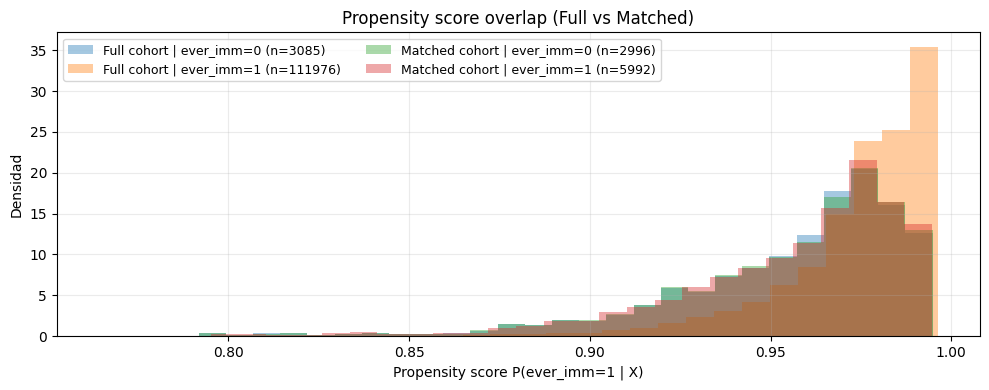

In [170]:
def fit_ps_and_score(df_base, covs, treat_col="ever_imm"):
    X_num = df_base[[c for c in covs if pd.api.types.is_numeric_dtype(df_base[c])]].copy()
    X_cat_cols = [c for c in covs if c not in X_num.columns]

    # one-hot en categóricas (fit en este df)
    if X_cat_cols:
        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        X_cat = enc.fit_transform(df_base[X_cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(X_cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        enc = None
        X = X_num.fillna(0)

    y = df_base[treat_col].astype(int).values

    model = LogisticRegression(max_iter=2000, solver="lbfgs")
    model.fit(X, y)
    ps = model.predict_proba(X)[:, 1]
    return model, enc, X_num.columns.tolist(), X_cat_cols, ps

def score_ps(df_base, covs, model, enc, num_cols, cat_cols):
    X_num = df_base[num_cols].copy() if num_cols else pd.DataFrame(index=df_base.index)
    if cat_cols:
        X_cat = enc.transform(df_base[cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        X = X_num.fillna(0)

    return model.predict_proba(X)[:, 1]

# Fit PS en full (pre)
ps_covs = base_covs_pre  # puedes ajustar
ps_model, ps_enc, num_cols, cat_cols, ps_pre = fit_ps_and_score(df_base_pre, ps_covs)

df_base_pre = df_base_pre.copy()
df_base_post = df_base_post.copy()
df_base_pre["ps"] = ps_pre
df_base_post["ps"] = score_ps(df_base_post, ps_covs, ps_model, ps_enc, num_cols, cat_cols)

def plot_ps_overlap(df_pre, df_post, treat_col="ever_imm", bins=30):
    fig, ax = plt.subplots(figsize=(10, 4))

    for df_, label in [(df_pre,"Full cohort"), (df_post,"Matched cohort")]:
        for tval in [0,1]:
            sub = df_[df_[treat_col]==tval]["ps"].dropna()
            ax.hist(sub, bins=bins, density=True, alpha=0.4,
                    label=f"{label} | ever_imm={tval} (n={len(sub)})")

    ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
    ax.set_ylabel("Densidad")
    ax.set_title("Propensity score overlap (Full vs Matched)")
    ax.grid(alpha=0.25)
    ax.legend(ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

plot_ps_overlap(df_base_pre, df_base_post)


In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

ID = "RUN"

COVS_NUM = ["SEMANAS"]
COVS_CAT = ["mes_nac_name", "region", "sexo"]

origin = pd.Timestamp("2025-03-01")  # inicio campaña (ajusta si corresponde)

def make_baseline_df(df_tv, df_base=None, id_col=ID, fecha_inm_col="fechaInm"):
    """
    Construye un DF basal (1 fila por RUN) desde un df time-varying (df_tv).
    Si df_base se entrega, hace merge por RUN para traer fechaInm y covariables.
    """
    # 1 fila por RUN desde df_tv
    d = df_tv[[id_col]].drop_duplicates().copy()

    if df_base is not None:
        keep = [id_col, fecha_inm_col] + COVS_NUM + COVS_CAT
        b = df_base[keep].drop_duplicates(subset=[id_col]).copy()
        d = d.merge(b, on=id_col, how="left")
    else:
        # si ya vienen las cols en df_tv
        keep = [id_col, fecha_inm_col] + COVS_NUM + COVS_CAT
        have = [c for c in keep if c in df_tv.columns]
        d = d.merge(df_tv[have].drop_duplicates(subset=[id_col]), on=id_col, how="left")

    # ever_imm
    d["ever_imm"] = d[fecha_inm_col].notna().astype(int)

    # timing (solo para inmunizados)
    d[fecha_inm_col] = pd.to_datetime(d[fecha_inm_col], errors="coerce")
    d["day_inm"] = (d[fecha_inm_col] - origin).dt.days
    d["week_inm"] = np.floor(d["day_inm"] / 7).astype("float")  # float por NaN

    return d

# Full baseline (desde tu df time-varying full + df basal por RUN)
base_full = make_baseline_df(df_cox_vrs_mrz_ag, df_base=df_f_vrs_mrz_ag)

# Matched baseline (desde tu df time-varying matched + df basal por RUN)
base_matched = make_baseline_df(df_tv_matched, df_base=df_f_vrs_mrz_ag)



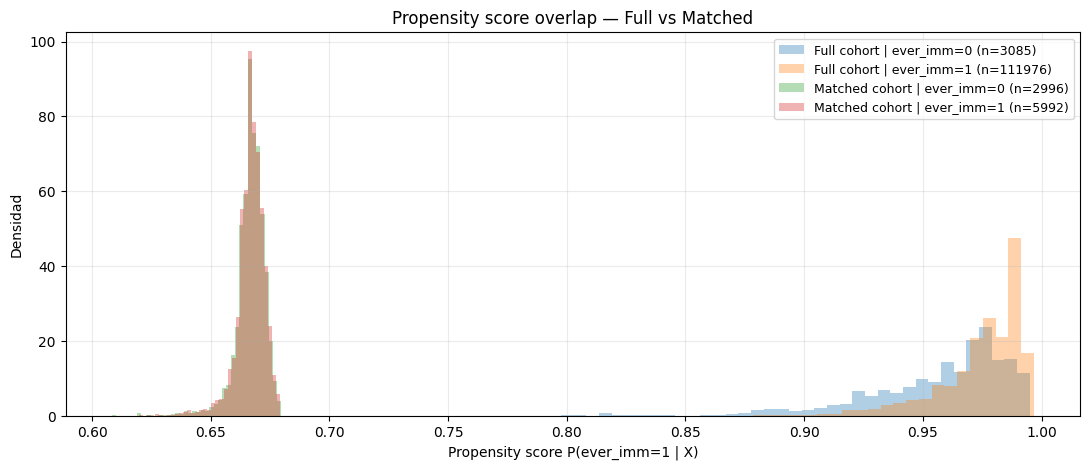

In [172]:
def fit_ps_and_score(df, y_col="ever_imm"):
    """
    Ajusta LogisticRegression para P(ever_imm=1 | X) con OHE para categóricas.
    Devuelve df con columna ps.
    """
    X = df[COVS_NUM + COVS_CAT].copy()
    y = df[y_col].astype(int)

    # pipeline: OHE para cat, passthrough num
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", COVS_NUM),
            ("cat", OneHotEncoder(handle_unknown="ignore"), COVS_CAT),
        ]
    )

    model = LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs")

    pipe = Pipeline(steps=[("pre", pre), ("lr", model)])
    pipe.fit(X, y)

    ps = pipe.predict_proba(X)[:, 1]
    out = df.copy()
    out["ps"] = ps
    return out

# Ajustar PS en FULL (recomendado) y aplicar el MISMO modelo a matched?
# Aquí, por simplicidad y consistencia, ajustamos por separado y comparamos distribuciones.
# Si quieres “misma escala exacta”, dime y lo dejamos entrenado en full y predicho en matched.

ps_full = fit_ps_and_score(base_full)
ps_matched = fit_ps_and_score(base_matched)

def plot_ps_overlap(ps_full, ps_matched, bins=40):
    fig, ax = plt.subplots(figsize=(11, 4.8))

    for df, name, alpha in [(ps_full, "Full cohort", 0.35), (ps_matched, "Matched cohort", 0.35)]:
        for g in [0, 1]:
            sub = df[df["ever_imm"] == g]["ps"].dropna()
            ax.hist(
                sub,
                bins=bins,
                density=True,
                alpha=alpha,
                label=f"{name} | ever_imm={g} (n={len(sub)})"
            )

    ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
    ax.set_ylabel("Densidad")
    ax.set_title("Propensity score overlap — Full vs Matched")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

plot_ps_overlap(ps_full, ps_matched)


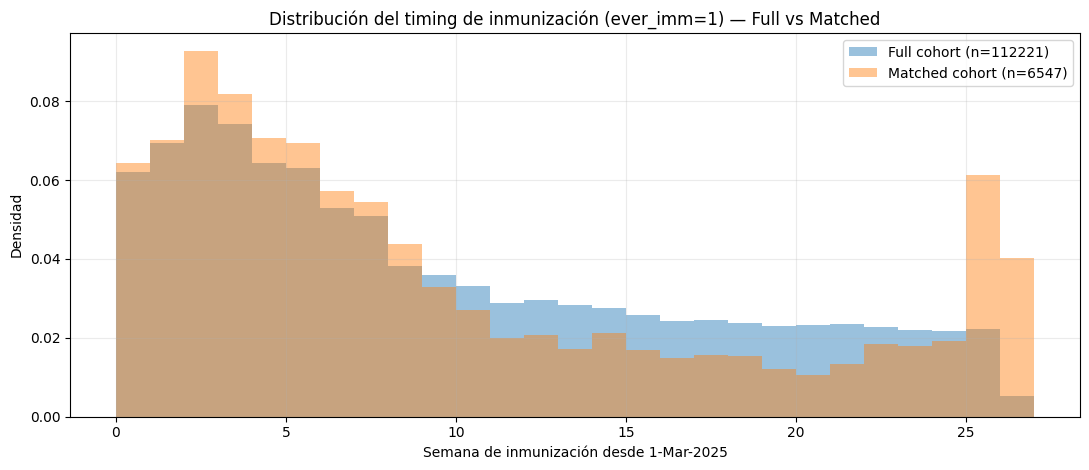

In [ ]:
def plot_week_inm_distribution(base_full, base_matched, week_max=None):
    # solo inmunizados
    a = base_full.query("ever_imm==1").copy()
    b = base_matched.query("ever_imm==1").copy()

    a = a.dropna(subset=["week_inm"])
    b = b.dropna(subset=["week_inm"])

    if week_max is not None:
        a = a[a["week_inm"] <= week_max]
        b = b[b["week_inm"] <= week_max]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    bins = np.arange(0, int(max(a["week_inm"].max(), b["week_inm"].max()) + 2))

    ax.hist(a["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Full cohort (n={len(a)})")
    ax.hist(b["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Matched cohort (n={len(b)})")

    ax.set_xlabel("Semana de inmunización desde 1-Mar-2025")
    ax.set_ylabel("Densidad")
    ax.set_title("Distribución del timing de inmunización (ever_imm=1) — Full vs Matched")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week_inm_distribution(base_full, base_matched, week_max=26)


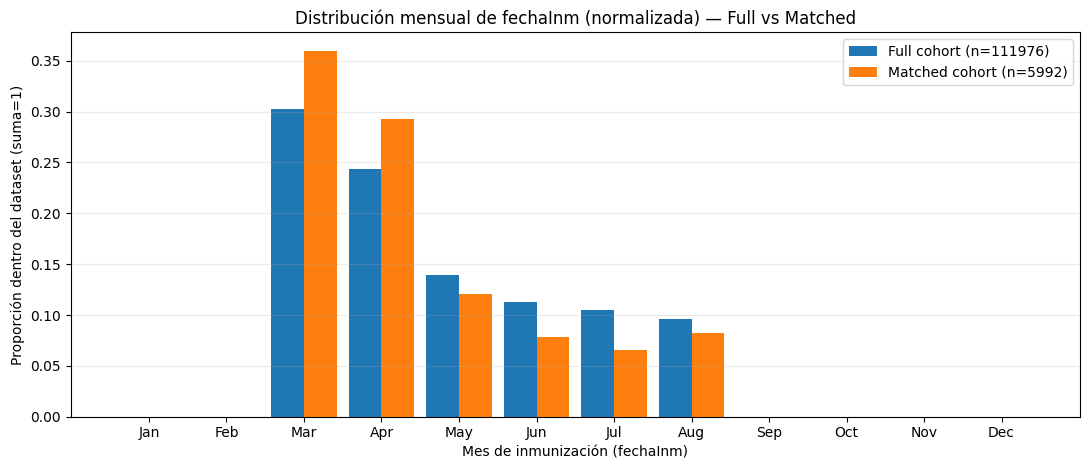

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asegurar datetime
base_full["fechaInm"] = pd.to_datetime(base_full["fechaInm"], errors="coerce")
base_matched["fechaInm"] = pd.to_datetime(base_matched["fechaInm"], errors="coerce")

# Mes (1-12) solo para inmunizados
full_m = base_full.loc[base_full["fechaInm"].notna(), "fechaInm"].dt.month
mat_m  = base_matched.loc[base_matched["fechaInm"].notna(), "fechaInm"].dt.month

months = np.arange(1, 13)
full_counts = full_m.value_counts().reindex(months, fill_value=0).sort_index()
mat_counts  = mat_m.value_counts().reindex(months, fill_value=0).sort_index()

# Normalizar dentro de cada dataset (cada uno suma 1)
full_props = full_counts / full_counts.sum() if full_counts.sum() > 0 else full_counts.astype(float)
mat_props  = mat_counts  / mat_counts.sum()  if mat_counts.sum()  > 0 else mat_counts.astype(float)

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

x = np.arange(len(months))
w = 0.42

fig, ax = plt.subplots(figsize=(11, 4.8))
ax.bar(x - w/2, full_props.values, width=w, label=f"Full cohort (n={int(full_counts.sum())})")
ax.bar(x + w/2, mat_props.values,  width=w, label=f"Matched cohort (n={int(mat_counts.sum())})")

ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Mes de inmunización (fechaInm)")
ax.set_ylabel("Proporción dentro del dataset (suma=1)")
ax.set_title("Distribución mensual de fechaInm (normalizada) — Full vs Matched")
ax.grid(axis="y", alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()



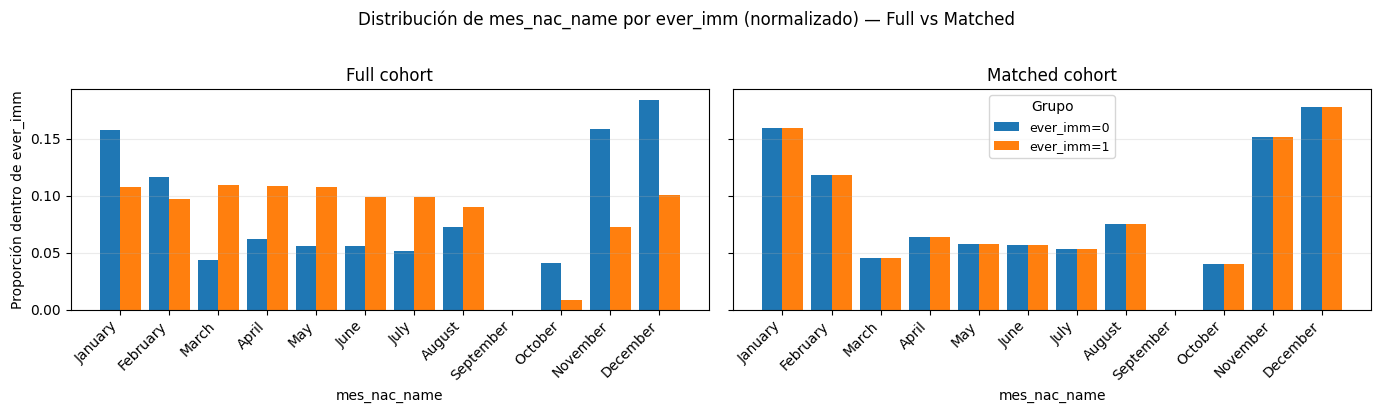

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que ya existen:
# - df_base_pre, df_base_post (1 fila por RUN con columna "ever_imm" y "mes_nac_name")
# - df_cox_vrs_mrz_ag (time-varying pre)
# - df_tv_matched (time-varying post)
# y nombres:
ID="RUN"; START="start"; STOP="stop"; IMM_TV="inmunizado"

# =========================================================
# 1) Distribución de mes_nac_name (barplot normalizado)
#    por ever_imm, full vs matched
# =========================================================

# Orden "bonito" (ajústalo a tu contexto, si tu temporada empieza Mar)
mes_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

def month_dist(df_base, label, month_col="mes_nac_name", treat_col="ever_imm"):
    d = df_base[[month_col, treat_col]].copy()
    d[month_col] = pd.Categorical(d[month_col], categories=mes_order, ordered=True)

    tab = (
        d.groupby([treat_col, month_col], dropna=False)
         .size()
         .reset_index(name="n")
    )
    tab["prop"] = tab.groupby(treat_col)["n"].transform(lambda x: x / x.sum())
    tab["dataset"] = label
    return tab

m_pre  = month_dist(df_base_pre,  "Full cohort")
m_post = month_dist(df_base_post, "Matched cohort")
m_all = pd.concat([m_pre, m_post], ignore_index=True)

# Plot: 2 paneles (Full vs Matched) y barras por ever_imm
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, ds in zip(axes, ["Full cohort", "Matched cohort"]):
    sub = m_all[m_all["dataset"] == ds].copy()
    # pivot para tener columnas 0/1 (ever_imm)
    pv = sub.pivot_table(index="mes_nac_name", columns="ever_imm", values="prop", fill_value=0).reindex(mes_order)
    x = np.arange(len(pv.index))
    w = 0.42

    ax.bar(x - w/2, pv.get(0, pd.Series(0, index=pv.index)), width=w, label="ever_imm=0")
    ax.bar(x + w/2, pv.get(1, pd.Series(0, index=pv.index)), width=w, label="ever_imm=1")

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(pv.index, rotation=45, ha="right")
    ax.grid(alpha=0.25, axis="y")
    ax.set_xlabel("mes_nac_name")

axes[0].set_ylabel("Proporción dentro de ever_imm")
axes[1].legend(title="Grupo", fontsize=9)
fig.suptitle("Distribución de mes_nac_name por ever_imm (normalizado) — Full vs Matched", y=1.02)
plt.tight_layout()
plt.show()


# =========================================================
# 2) Person-time por semana normalizado a proporción
#    (cada curva suma 1), full vs matched, por estado inmunizado
# =========================================================

# def add_week_mid_and_dt(df, start_col=START, stop_col=STOP):
#     d = df[[ID, start_col, stop_col, IMM_TV]].copy()
#     mid = (d[start_col].astype(float) + d[stop_col].astype(float)) / 2.0
#     d["week_mid"] = (mid // 7).astype(int)
#     d["dt"] = (d[stop_col].astype(float) - d[start_col].astype(float)).clip(lower=0)
#     return d

# def weekly_person_time_prop(df_tv, label):
#     d = add_week_mid_and_dt(df_tv)
#     pt = (
#         d.groupby(["week_mid", IMM_TV])["dt"].sum()
#          .reset_index()
#          .rename(columns={"dt":"person_days"})
#     )
#     # Normalizar: dentro de cada (dataset, inmunizado) que sume 1
#     pt["dataset"] = label
#     pt["prop_person_time"] = pt.groupby([ "dataset", IMM_TV ])["person_days"].transform(lambda x: x / x.sum())
#     return pt

# pt_prop_pre  = weekly_person_time_prop(df_cox_vrs_mrz_ag, "Full cohort")
# pt_prop_post = weekly_person_time_prop(df_tv_matched,     "Matched cohort")
# pt_prop = pd.concat([pt_prop_pre, pt_prop_post], ignore_index=True)

# # Plot: 2 paneles (inmunizado=0 e inmunizado=1), líneas Full vs Matched
# fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

# for ax, imm in zip(axes, [0, 1]):
#     for ds in ["Full cohort", "Matched cohort"]:
#         sub = pt_prop[(pt_prop["dataset"] == ds) & (pt_prop[IMM_TV] == imm)].sort_values("week_mid")
#         ax.plot(sub["week_mid"], sub["prop_person_time"], marker="o", linewidth=1, markersize=3, label=ds)

#     ax.set_title(f"inmunizado={imm}")
#     ax.set_xlabel("Semana (desde origen start/stop)")
#     ax.grid(alpha=0.25)

# axes[0].set_ylabel("Proporción del person-time (suma=1)")
# axes[1].legend(title="Dataset", fontsize=9)
# fig.suptitle("Person-time por semana (normalizado a proporción) — Full vs Matched", y=1.02)
# plt.tight_layout()
# plt.show()



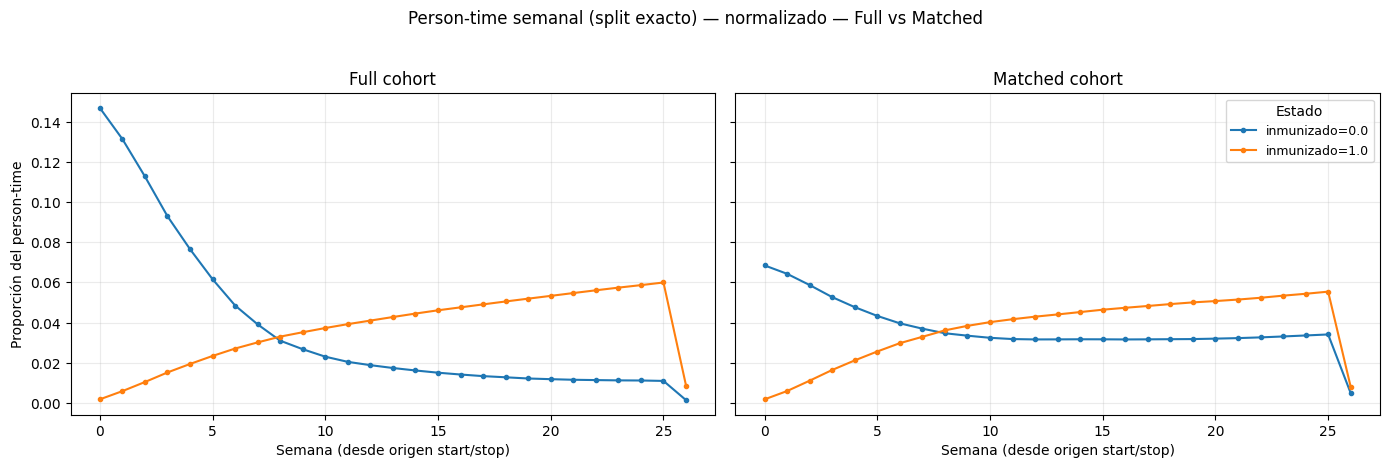

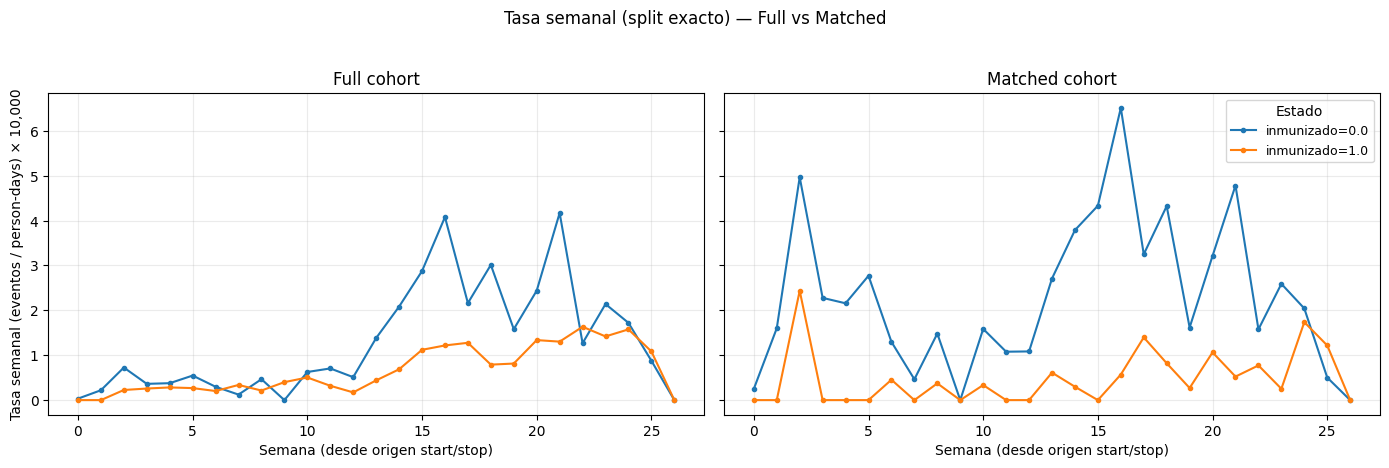

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ID    = "RUN"
START = "start"
STOP  = "stop"
IMM   = "inmunizado"
EVENT = "event_vrs"   # cambia si tu evento se llama distinto (o pon None si no quieres tasas)

EPS = 1e-9  # para manejar bien intervalos [start, stop)

def split_intervals_to_weeks(df, id_col=ID, start_col=START, stop_col=STOP, imm_col=IMM, event_col=EVENT):
    """
    Split exacto por semana de intervalos [start, stop).
    Devuelve DF expandido con columnas: week, seg_start, seg_stop, dt, (event_week si event_col no es None).
    Sin loop por filas: usa np.repeat + concat de rangos por fila.
    """
    cols = [id_col, start_col, stop_col, imm_col] + ([event_col] if event_col else [])
    d = df[cols].copy()

    # Asegurar numérico
    d[start_col] = pd.to_numeric(d[start_col], errors="coerce")
    d[stop_col]  = pd.to_numeric(d[stop_col],  errors="coerce")
    d = d.dropna(subset=[start_col, stop_col, imm_col, id_col])

    # Intervalos válidos
    d = d[d[stop_col] > d[start_col]].copy()

    start = d[start_col].to_numpy(float)
    stop  = d[stop_col].to_numpy(float)

    # semanas que intersecta el intervalo
    w_start = np.floor(start / 7.0).astype(int)
    w_end   = np.floor((stop - EPS) / 7.0).astype(int)  # última semana con algo de tiempo

    n_weeks = (w_end - w_start + 1)
    n_weeks = np.maximum(n_weeks, 0)

    # Índices repetidos (expand)
    rep_idx = np.repeat(d.index.to_numpy(), n_weeks)

    # Construir vector weeks expandido (concat de arange por fila)
    # (esto evita apply/explode por fila; el único “loop” es sobre n_weeks para armar el array de weeks)
    weeks = np.concatenate([np.arange(ws, we + 1) for ws, we in zip(w_start, w_end)])

    out = d.loc[rep_idx].copy()
    out["week"] = weeks

    # Segmento exacto dentro de cada semana: [max(start, week*7), min(stop, (week+1)*7))
    w0 = out["week"].to_numpy(int) * 7.0
    w1 = (out["week"].to_numpy(int) + 1) * 7.0

    s = out[start_col].to_numpy(float)
    t = out[stop_col].to_numpy(float)

    seg_start = np.maximum(s, w0)
    seg_stop  = np.minimum(t, w1)
    dt = (seg_stop - seg_start)
    dt = np.clip(dt, 0, None)

    out["seg_start"] = seg_start
    out["seg_stop"]  = seg_stop
    out["dt"]        = dt

    # Evento: asignarlo SOLO al split-row que contiene el "stop" del intervalo donde ocurre el evento
    # (asume event_col=1 indica que el evento ocurre al final de ese intervalo)
    if event_col:
        event = out[event_col].to_numpy()
        stop_week = np.floor((t - EPS) / 7.0).astype(int)  # semana donde cae stop
        out["event_week"] = ((event == 1) & (out["week"].to_numpy(int) == stop_week)).astype(int)

    # Filtrar splits sin tiempo (por seguridad)
    out = out[out["dt"] > 0].copy()

    return out


def weekly_aggregate(df_week, id_col=ID, imm_col=IMM, event_week_col="event_week"):
    """
    Agrega por semana e inmunizado:
    - person_days
    - n_RUN_active (RUN únicos con dt>0)
    - n_intervals
    - events (si existe event_week_col)
    - rate_per_10k (si existe)
    """
    gcols = ["week", imm_col]

    agg = (
        df_week.groupby(gcols)
               .agg(
                   person_days=("dt", "sum"),
                   n_intervals=("dt", "size"),
                   n_RUN_active=(id_col, "nunique"),
               )
               .reset_index()
               .sort_values(["week", imm_col])
    )
    
    if event_week_col in df_week.columns:
        ev = (
            df_week.groupby(gcols)[event_week_col]
                   .sum()
                   .reset_index(name="events")
        )
        agg = agg.merge(ev, on=gcols, how="left")
        agg["events"] = agg["events"].fillna(0).astype(int)
        agg["rate_per_10k"] = agg["events"] / agg["person_days"] * 10000.0

    # Proporción de person-time (suma=1 dentro de cada inmunizado)
    agg["pt_prop"] = agg.groupby(imm_col)["person_days"].transform(lambda x: x / x.sum())

    return agg


def plot_pt_prop_full_vs_matched(agg_full, agg_matched, imm_col=IMM):
    """
    2 subplots: Full vs Matched.
    En cada subplot: líneas normalizadas (pt_prop) para inmunizado=0 y 1.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

    for ax, agg, title in zip(axes, [agg_full, agg_matched], ["Full cohort", "Matched cohort"]):
        for imm in sorted(agg[imm_col].dropna().unique()):
            sub = agg[agg[imm_col] == imm].sort_values("week")
            ax.plot(sub["week"], sub["pt_prop"], marker="o", linewidth=1.5, markersize=3, label=f"{imm_col}={imm}")

        ax.set_title(title)
        ax.set_xlabel("Semana (desde origen start/stop)")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Proporción del person-time")
    axes[1].legend(title="Estado", fontsize=9)
    fig.suptitle("Person-time semanal (split exacto) — normalizado — Full vs Matched", y=1.03)
    plt.tight_layout()
    plt.show()


def plot_rate_full_vs_matched(agg_full, agg_matched, imm_col=IMM):
    """
    2 subplots: Full vs Matched.
    Tasa semanal: events/person_days * 10k (requiere event_week).
    """
    if "rate_per_10k" not in agg_full.columns or "rate_per_10k" not in agg_matched.columns:
        print("No encontré rate_per_10k (falta event_week). Asegúrate de pasar EVENT correctamente.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)

    for ax, agg, title in zip(axes, [agg_full, agg_matched], ["Full cohort", "Matched cohort"]):
        for imm in sorted(agg[imm_col].dropna().unique()):
            sub = agg[agg[imm_col] == imm].sort_values("week")
            ax.plot(sub["week"], sub["rate_per_10k"], marker="o", linewidth=1.5, markersize=3, label=f"{imm_col}={imm}")

        ax.set_title(title)
        ax.set_xlabel("Semana (desde origen start/stop)")
        ax.grid(alpha=0.25)

    axes[0].set_ylabel("Tasa semanal (eventos / person-days) × 10,000")
    axes[1].legend(title="Estado", fontsize=9)
    fig.suptitle("Tasa semanal (split exacto) — Full vs Matched", y=1.03)
    plt.tight_layout()
    plt.show()


# =========================================================
# USO: Full vs Matched
# =========================================================
# df_cox_vrs_mrz_ag = tu base time-varying full
# df_tv_matched     = tu base time-varying matched

dfw_full    = split_intervals_to_weeks(df_cox_vrs_mrz_ag, event_col=EVENT)
dfw_matched = split_intervals_to_weeks(df_tv_matched,     event_col=EVENT)

agg_full    = weekly_aggregate(dfw_full,    event_week_col="event_week")
agg_matched = weekly_aggregate(dfw_matched, event_week_col="event_week")

# (1) Person-time normalizado (suma=1 por inmunizado) — 2 subplots Full vs Matched
plot_pt_prop_full_vs_matched(agg_full, agg_matched)

# (2) (Opcional) Tasas semanales (requiere EVENT)
plot_rate_full_vs_matched(agg_full, agg_matched)

# (3) (Opcional) Tablas "lindas" para inspeccionar picos:
# display(agg_matched.sort_values("person_days", ascending=False).head(15))
# display(agg_matched.sort_values("n_RUN_active", ascending=False).head(15))


PARTEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE

Covariables basales (pre): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'eleg_2025', 'categori_macro', 'percent_poor']
Covariables basales (post): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'eleg_2025', 'categori_macro', 'percent_poor']
(115061, 12) (8988, 12)


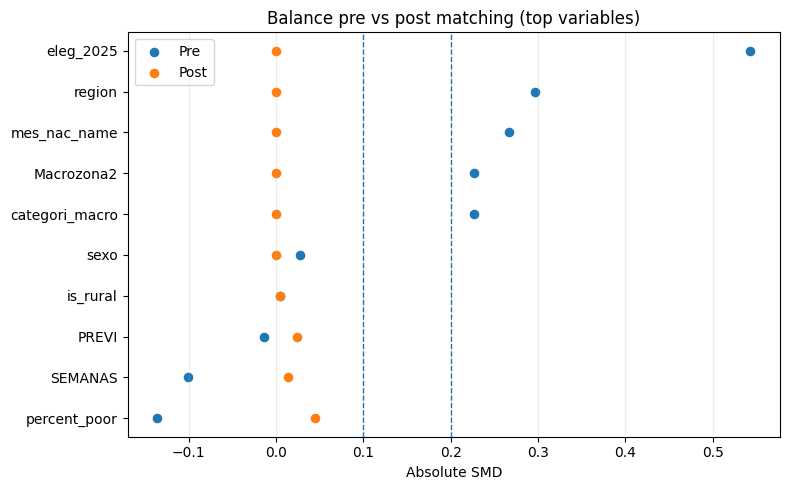

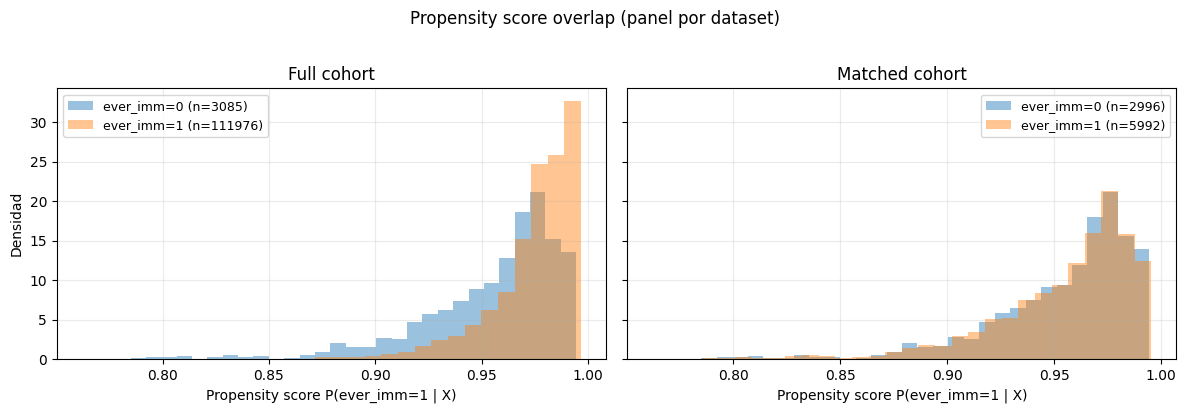

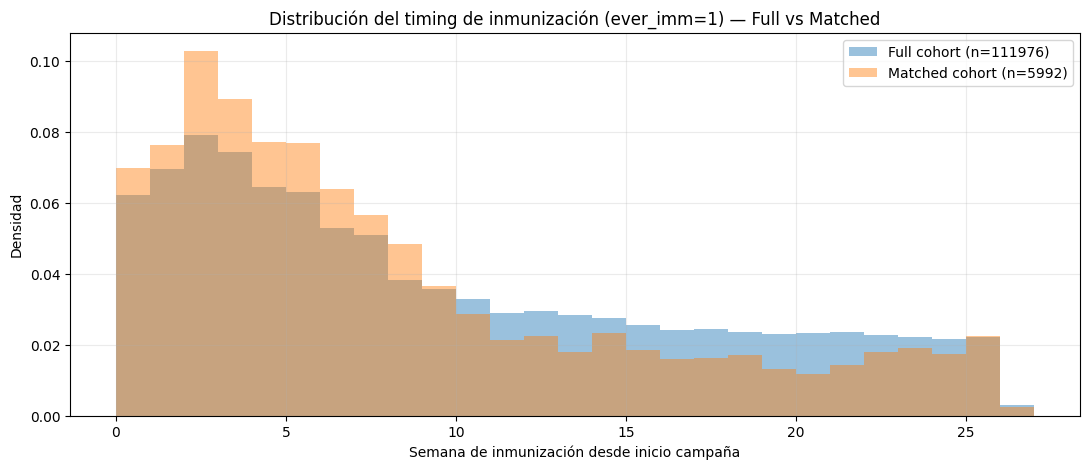

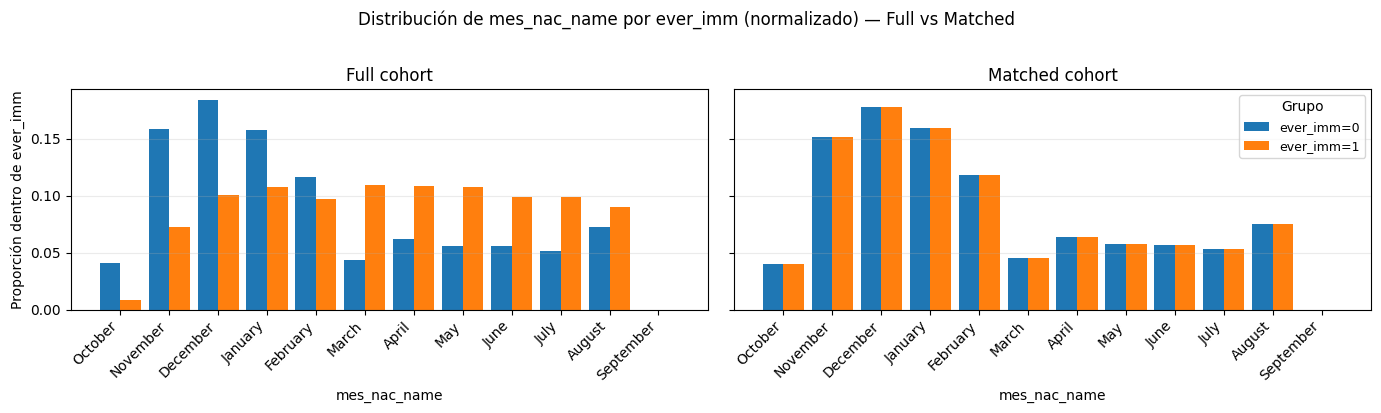

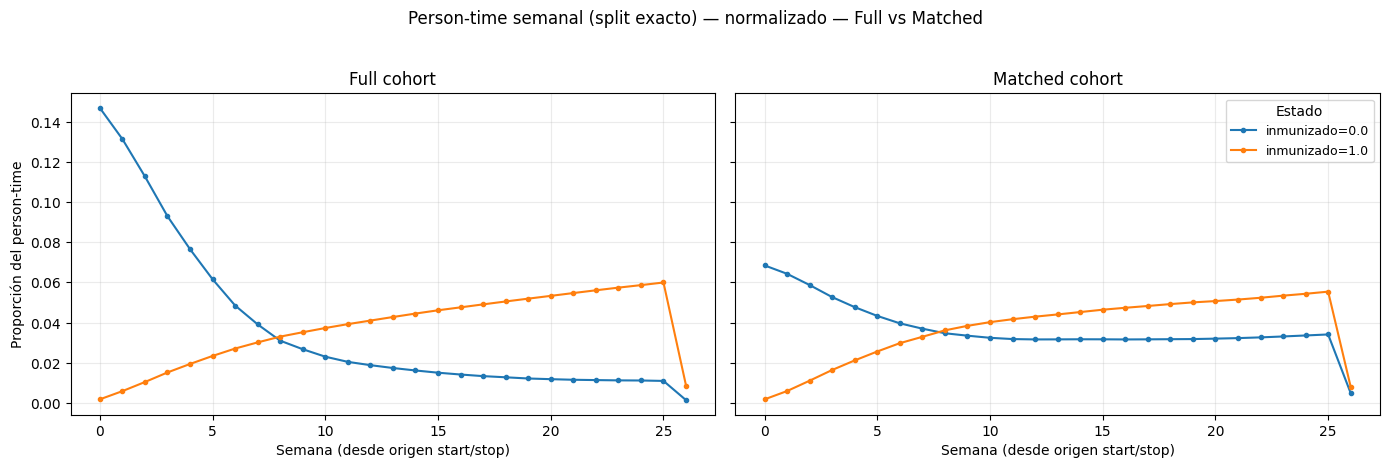

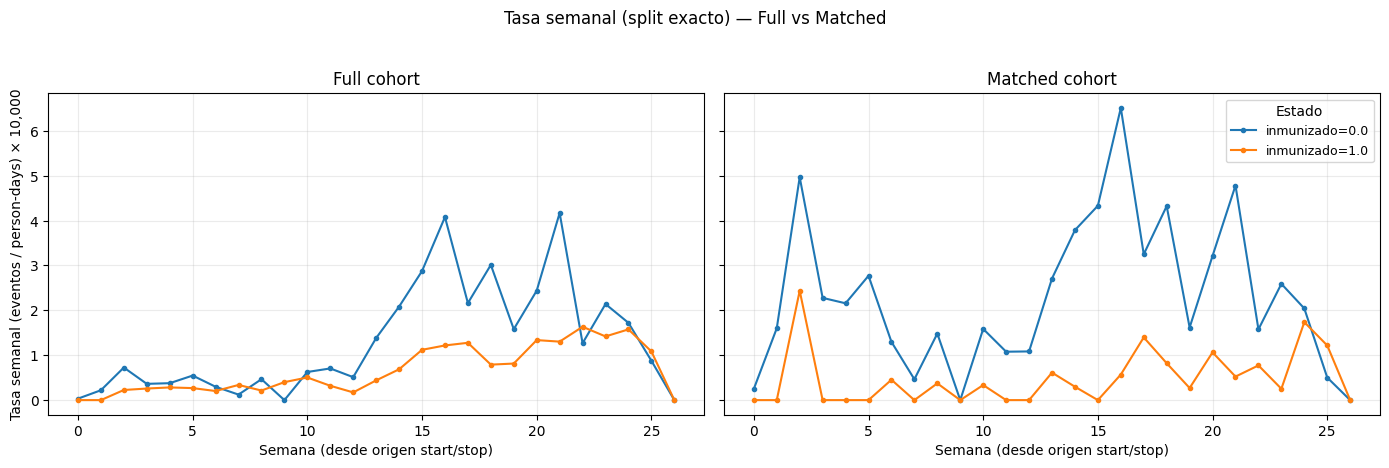

In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---------------------------
# Helpers básicos
# ---------------------------
ID = "RUN"
START = "start"
STOP = "stop"
EVENT = "event_vrs"
IMM_TV = "inmunizado"   # time-varying 0/1
MATCH_GROUP = "Group"   # solo en df_tv_matched


candidate_covs = [
    "sexo", "region", "Macrozona2", "PREVI", "SEMANAS", "mes_nac_name",
    "is_rural", "eleg_2025", "categori_macro", "categoric_regions", "percent_poor", "percent_rural"
]

# Filtramos solo las que existen en tu df
base_covs_pre = [c for c in candidate_covs if c in df_cox_vrs_mrz_ag.columns]
base_covs_post = [c for c in candidate_covs if c in df_tv_matched.columns]

print("Covariables basales (pre):", base_covs_pre)
print("Covariables basales (post):", base_covs_post)

# Baseline pre y post
df_base_pre = make_baseline(df_cox_vrs_mrz_ag, keep_cols=[ID] + base_covs_pre)
df_base_post = make_baseline(df_tv_matched, keep_cols=[ID] + base_covs_post)

print(df_base_pre.shape, df_base_post.shape)

smd_pre = compute_smd_table(df_base_pre, base_covs_pre)
smd_post = compute_smd_table(df_base_post, base_covs_post)

# Combinar en una tabla bonita
smd = (smd_pre.rename(columns={"SMD":"SMD_pre"})
              .merge(smd_post.rename(columns={"SMD":"SMD_post"})[["variable","SMD_post"]],
                     on="variable", how="outer")
              .sort_values(["SMD_pre","SMD_post"], ascending=False))

love_plot(smd, top=25)

# plot_ps_overlap(df_base_pre, df_base_post)

COVS_NUM = ["SEMANAS"]
COVS_CAT = ["mes_nac_name", "region", "sexo"]

origin = pd.Timestamp("2025-03-01")  # inicio campaña (ajusta si corresponde)

# Full baseline (desde tu df time-varying full + df basal por RUN)
base_full = make_baseline_df(df_cox_vrs_mrz_ag, df_base=df_f_vrs_mrz_ag)

# Matched baseline (desde tu df time-varying matched + df basal por RUN)
base_matched = make_baseline_df(df_tv_matched, df_base=df_f_vrs_mrz_ag)



# Ajustar PS en FULL (recomendado) y aplicar el MISMO modelo a matched?
# Aquí, por simplicidad y consistencia, ajustamos por separado y comparamos distribuciones.
# Si quieres “misma escala exacta”, dime y lo dejamos entrenado en full y predicho en matched.

def fit_ps_and_score(df, y_col="ever_imm"):
    """
    Ajusta LogisticRegression para P(ever_imm=1 | X) con OHE para categóricas.
    Devuelve df con columna ps.
    """
    X = df[COVS_NUM + COVS_CAT].copy()
    y = df[y_col].astype(int)

    # pipeline: OHE para cat, passthrough num
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", COVS_NUM),
            ("cat", OneHotEncoder(handle_unknown="ignore"), COVS_CAT),
        ]
    )

    model = LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs")

    pipe = Pipeline(steps=[("pre", pre), ("lr", model)])
    pipe.fit(X, y)

    ps = pipe.predict_proba(X)[:, 1]
    out = df.copy()
    out["ps"] = ps
    return out


# ps_full = fit_ps_and_score(base_full)
# ps_matched = fit_ps_and_score(base_matched)

# plot_ps_overlap(ps_full, ps_matched)

def fit_ps_and_score(df_base, covs, treat_col="ever_imm"):
    X_num = df_base[[c for c in covs if pd.api.types.is_numeric_dtype(df_base[c])]].copy()
    X_cat_cols = [c for c in covs if c not in X_num.columns]

    # one-hot en categóricas (fit en este df)
    if X_cat_cols:
        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        X_cat = enc.fit_transform(df_base[X_cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(X_cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        enc = None
        X = X_num.fillna(0)

    y = df_base[treat_col].astype(int).values

    model = LogisticRegression(max_iter=2000, solver="lbfgs")
    model.fit(X, y)
    ps = model.predict_proba(X)[:, 1]
    return model, enc, X_num.columns.tolist(), X_cat_cols, ps

def score_ps(df_base, covs, model, enc, num_cols, cat_cols):
    X_num = df_base[num_cols].copy() if num_cols else pd.DataFrame(index=df_base.index)
    if cat_cols:
        X_cat = enc.transform(df_base[cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        X = X_num.fillna(0)

    return model.predict_proba(X)[:, 1]

# Fit PS en full (pre)
ps_covs = base_covs_pre  # puedes ajustar
ps_model, ps_enc, num_cols, cat_cols, ps_pre = fit_ps_and_score(df_base_pre, ps_covs)

df_base_pre = df_base_pre.copy()
df_base_post = df_base_post.copy()
df_base_pre["ps"] = ps_pre
df_base_post["ps"] = score_ps(df_base_post, ps_covs, ps_model, ps_enc, num_cols, cat_cols)

def plot_ps_overlap_2panels(df_pre, df_post, treat_col="ever_imm", bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def _panel(ax, df_, title):
        for tval in [0, 1]:
            sub = df_.loc[df_[treat_col] == tval, "ps"].dropna()
            ax.hist(sub, bins=bins, density=True, alpha=0.45,
                    label=f"ever_imm={tval} (n={len(sub)})")
        ax.set_title(title)
        ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    _panel(axes[0], df_pre,  "Full cohort")
    _panel(axes[1], df_post, "Matched cohort")

    axes[0].set_ylabel("Densidad")
    fig.suptitle("Propensity score overlap (panel por dataset)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_ps_overlap_2panels(df_base_pre, df_base_post, treat_col="ever_imm", bins=30)


def plot_week_inm_distribution(base_full, base_matched, week_max=None):
    # solo inmunizados
    a = base_full.query("ever_imm==1").copy()
    b = base_matched.query("ever_imm==1").copy()

    a = a.dropna(subset=["week_inm"])
    b = b.dropna(subset=["week_inm"])

    if week_max is not None:
        a = a[a["week_inm"] <= week_max]
        b = b[b["week_inm"] <= week_max]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    bins = np.arange(0, int(max(a["week_inm"].max(), b["week_inm"].max()) + 2))

    ax.hist(a["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Full cohort (n={len(a)})")
    ax.hist(b["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Matched cohort (n={len(b)})")

    ax.set_xlabel("Semana de inmunización desde inicio campaña")
    ax.set_ylabel("Densidad")
    ax.set_title("Distribución del timing de inmunización (ever_imm=1) — Full vs Matched")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week_inm_distribution(base_full, base_matched, week_max=26)


ID="RUN"; START="start"; STOP="stop"; IMM_TV="inmunizado"


# Orden "bonito" (ajústalo a tu contexto, si tu temporada empieza Mar)
mes_order = [
    "October","November","December","January","February",
    "March","April","May","June","July","August","September"
]

pt_pre, ev_pre = weekly_person_time_and_events(df_cox_vrs_mrz_ag, "Full cohort")
pt_post, ev_post = weekly_person_time_and_events(df_tv_matched, "Matched cohort")

pt_all = pd.concat([pt_pre, pt_post], ignore_index=True)
ev_all = pd.concat([ev_pre, ev_post], ignore_index=True)

# Incidence rate por 10,000 person-days (para comparar)
df_ir = (pt_all.merge(ev_all, on=["dataset","week_mid", IMM_TV], how="left")
              .fillna({"events":0})
              .assign(rate_per_10k=lambda x: 10000 * x["events"] / x["person_days"].replace(0, np.nan)))

def month_dist(df_base, label, month_col="mes_nac_name", treat_col="ever_imm"):
    d = df_base[[month_col, treat_col]].copy()
    d[month_col] = pd.Categorical(d[month_col], categories=mes_order, ordered=True)

    tab = (
        d.groupby([treat_col, month_col], dropna=False)
         .size()
         .reset_index(name="n")
    )
    tab["prop"] = tab.groupby(treat_col)["n"].transform(lambda x: x / x.sum())
    tab["dataset"] = label
    return tab

m_pre  = month_dist(df_base_pre,  "Full cohort")
m_post = month_dist(df_base_post, "Matched cohort")
m_all = pd.concat([m_pre, m_post], ignore_index=True)

# Plot: 2 paneles (Full vs Matched) y barras por ever_imm
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, ds in zip(axes, ["Full cohort", "Matched cohort"]):
    sub = m_all[m_all["dataset"] == ds].copy()
    # pivot para tener columnas 0/1 (ever_imm)
    pv = sub.pivot_table(index="mes_nac_name", columns="ever_imm", values="prop", fill_value=0).reindex(mes_order)
    x = np.arange(len(pv.index))
    w = 0.42

    ax.bar(x - w/2, pv.get(0, pd.Series(0, index=pv.index)), width=w, label="ever_imm=0")
    ax.bar(x + w/2, pv.get(1, pd.Series(0, index=pv.index)), width=w, label="ever_imm=1")

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(pv.index, rotation=45, ha="right")
    ax.grid(alpha=0.25, axis="y")
    ax.set_xlabel("mes_nac_name")

axes[0].set_ylabel("Proporción dentro de ever_imm")
axes[1].legend(title="Grupo", fontsize=9)
fig.suptitle("Distribución de mes_nac_name por ever_imm (normalizado) — Full vs Matched", y=1.02)
plt.tight_layout()
plt.show()

IMM   = "inmunizado"

EPS = 1e-9  # para manejar bien intervalos [start, stop)



dfw_full    = split_intervals_to_weeks(df_cox_vrs_mrz_ag, event_col=EVENT)
dfw_matched = split_intervals_to_weeks(df_tv_matched,     event_col=EVENT)

agg_full    = weekly_aggregate(dfw_full,    event_week_col="event_week")
agg_matched = weekly_aggregate(dfw_matched, event_week_col="event_week")

plot_pt_prop_full_vs_matched(agg_full, agg_matched)

plot_rate_full_vs_matched(agg_full, agg_matched)

TERMINAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAAA

In [ ]:
################################################################## CODIGO MAXIMIZACION RATIO ##################################################################
from matching_case_control import match_nn_max_dist_weigths
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

lista_ratios = ['1:1','1:2','1:3','1:4','1:5','1:6','1:7','1:8','1:9','1:10']
resultados_ratio = {}
for r in lista_ratios:
    base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

    df_tv = df_cox_vrs_mrz_ag.copy()

    df_base = (
        df_tv.sort_values(['RUN', "start"])
            .groupby('RUN', as_index=False)
            .first()[['RUN'] + base_covs]
    )

    ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
    df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
    df_base["ever_imm"] = df_base["ever_imm"].astype(int)

    df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
    df_control = df_base.query("ever_imm == 1").copy() 

    match_vars_nn     = ['semana_nac','SEMANAS']
    match_vars_exact  = ["sexo", "region",'mes_nac_name']

    matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
        df_control=df_control,
        df_case=df_cases,
        match_vars_nn=match_vars_nn,
        match_vars_exact=match_vars_exact,
        ratio=r,
        max_distance=5.0
    )

    match_map = matched_base[["RUN", "Group"]].drop_duplicates()
    df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

    ctv = CoxTimeVaryingFitter()

    ctv.fit(
        df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
        id_col="RUN",
        start_col="start",
        stop_col="stop",
        event_col="event_vrs",
        strata=["Group"],
        show_progress=True
    )
    resultados_ratio[r] = printSummary(ctv)

1:1 ['1', '1']
here aaa
Total cases = 3994, Total controls = 111976
Total cases matched is : 3679, Total control matched is : 3679
ratio: 1:1
No matched : 315
Iteration 1: norm_delta = 5.50e-01, step_size = 0.9500, log_lik = -115.75558, newton_decrement = 2.42e+01, seconds_since_start = 2.3
Iteration 2: norm_delta = 1.07e-01, step_size = 0.9500, log_lik = -90.46211, newton_decrement = 6.76e-01, seconds_since_start = 4.6
Iteration 3: norm_delta = 1.29e-02, step_size = 0.9500, log_lik = -89.76362, newton_decrement = 8.62e-03, seconds_since_start = 7.0
Iteration 4: norm_delta = 7.97e-04, step_size = 1.0000, log_lik = -89.75498, newton_decrement = 2.92e-05, seconds_since_start = 9.3
Iteration 5: norm_delta = 4.04e-07, step_size = 1.0000, log_lik = -89.75495, newton_decrement = 7.46e-12, seconds_since_start = 11.5
Convergence completed after 5 iterations.
1:2 ['1', '2']
here aaa
Total cases = 3994, Total controls = 111976
Total cases matched is : 3662, Total control matched is : 7324
ratio:

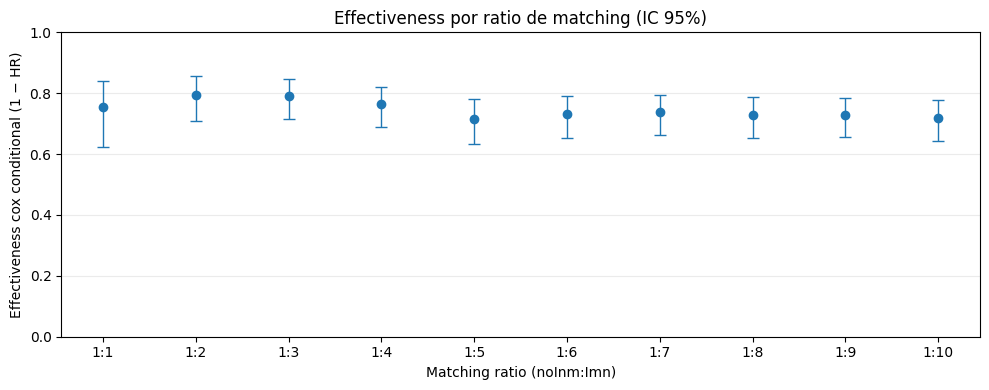

,ratio,ratio_num,effectiveness,eff_lower_95,eff_upper_95
0,1:1,1.0,0.754717,0.623337,0.840272
1,1:2,2.0,0.794507,0.707669,0.855549
2,1:3,3.0,0.791303,0.715657,0.846824
3,1:4,4.0,0.764042,0.688674,0.821164
4,1:5,5.0,0.715656,0.631853,0.780382
5,1:6,6.0,0.730660,0.653274,0.790775
6,1:7,7.0,0.737021,0.662504,0.795086
7,1:8,8.0,0.728438,0.654390,0.786620
8,1:9,9.0,0.728775,0.656648,0.785751
9,1:10,10.0,0.717206,0.642556,0.776266


In [ ]:
import re

def _ratio_key(r):
    """
    Ordena ratios numéricamente.
    Ej: "1:1" -> 1.0, "1:3" -> 3.0, "2:1" -> 0.5, etc.
    """
    m = re.match(r"^\s*(\d+)\s*:\s*(\d+)\s*$", str(r))
    if not m:
        return np.inf
    a, b = int(m.group(1)), int(m.group(2))
    return b / a if a != 0 else np.inf

rows = []
for ratio, df in resultados_ratio.items():
    if df is None or len(df) == 0:
        continue

    # Asegurar que "inmunizado" esté en el índice
    if "inmunizado" in df.index:
        s = df.loc["inmunizado"]
    else:
        # fallback si viene como columna "covariate"
        if "covariate" in df.columns:
            s = df.loc[df["covariate"] == "inmunizado"].iloc[0]
        else:
            raise ValueError(f"No encuentro 'inmunizado' en índice ni columna covariate para ratio={ratio}")

    rows.append({
        "ratio": ratio,
        "ratio_num": _ratio_key(ratio),
        "effectiveness": float(s["effectiveness"]),
        "eff_lower_95": float(s["eff_lower_95"]),
        "eff_upper_95": float(s["eff_upper_95"]),
    })

plot_df = pd.DataFrame(rows).sort_values("ratio_num").reset_index(drop=True)

# --- Plot ---
x = np.arange(len(plot_df))
y = plot_df["effectiveness"].to_numpy()
yerr_low = y - plot_df["eff_lower_95"].to_numpy()
yerr_up  = plot_df["eff_upper_95"].to_numpy() - y
yerr = np.vstack([yerr_low, yerr_up])

fig, ax = plt.subplots(figsize=(10, 4))

ax.errorbar(
    x, y,
    yerr=yerr,
    fmt="o",
    capsize=4,
    linewidth=1
)

# opcional: unir puntos
# ax.plot(x, y)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["ratio"].tolist(), rotation=0)
ax.set_xlabel("Matching ratio (noInm:Imn)")
ax.set_ylabel("Effectiveness cox conditional (1 − HR)")
ax.set_title("Effectiveness por ratio de matching (IC 95%)")
ax.grid(alpha=0.25, axis="y")

# Si quieres fijar el rango 0-1 (típico para efectividad)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# display(plot_df)


In [ ]:
###################################################################### matching ps ########################################################
from matching_case_control import match_ps_max_dist_weights

base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_mrz_ag.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_ps_max_dist_weights(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:3",
    max_distance=0.02
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

[PS MATCH] ratio=1:3  (case:control = 1:3)
[PS MATCH] Total cases    = 3994
[PS MATCH] Total controls = 111976
[PS MATCH] PS summary - cases:
count    3994.000000
mean        0.960283
std         0.014756
min         0.919416
5%          0.937923
50%         0.959145
95%         0.980359
max         0.982188
[PS MATCH] PS summary - controls:
count    111976.000000
mean          0.965746
std           0.012907
min           0.913747
5%            0.939327
50%           0.969152
95%           0.980339
max           0.982188
[PS MATCH] Matched cases (unique RUN)   = 3938
[PS MATCH] Matched controls (rows)      = 11814
[PS MATCH] Unmatched primary units      = 56
Iteration 1: norm_delta = 8.31e-01, step_size = 0.9500, log_lik = -308.80384, newton_decrement = 6.05e+01, seconds_since_start = 2.6
Iteration 2: norm_delta = 7.07e-02, step_size = 0.9500, log_lik = -255.76016, newton_decrement = 4.76e-01, seconds_since_start = 5.0
Iteration 3: norm_delta = 2.05e-03, step_size = 0.9500, log_lik = 

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.521007,0.781508,0.149974,-1.81495,-1.227063,0.706848,0.837154,0.0


In [ ]:
######################################################################  con charly_doble s edemora 100 años ##########################################
from matching_case_control import charly_double_mip

distance_vars = ['semana_nac','SEMANAS']            
exact_vars    = ['sexo','region','mes_nac_name']     
ratio = "1:2"

matched_base, feasible_controls, cases, controls, ratio_out, n_ctrl, n_case = charly_double_mip(
    df_cases=df_cases,
    df_control=df_control.sample(frac=0.20, random_state=42),
    distance_vars=distance_vars,
    exact_var_match=exact_vars,
    ratio=ratio
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()

# Subsetear df_tv a solo RUNs matched y pegar Group
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

# en el modelo normalmente basta con la exposición time-varying
model_covs = ['inmunizado']  # puedes agregar covariables que varíen dentro del set si corresponde

ctv = CoxTimeVaryingFitter()  # si hay inestabilidad prueba 0.01–1

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", 'event_vrs', "Group"] + model_covs],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col='event_vrs',
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

creacion conjuntos A_i time: 13.067854642868042
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-07
creacion variables time: 383.63590478897095
9.723780354488367
optimize model 1 time: 24.751463174819946
optimize model 2 time: 7162.092482328415
matched_data time: 4.417201519012451
Total cases = 3994, Total controls = 22395
Total cases matched is : 3748, Total control matched is : 7496
ratio: 1:2
Iteration 1: norm_delta = 7.11e-01, step_size = 0.9500, log_lik = -213.01300, newton_decrement = 4.40e+01, seconds_since_start = 2.3
Iteration 2: norm_delta = 1.46e-02, step_size = 0.9500, log_lik = -171.05227, newton_decrement = 1.70e-02, seconds_since_start = 4.7
Iteration 3: norm_delta = 8.19e-04, step_size = 0.9500, log_lik = -171.03527, newton_decrement = 5.27e-05, seconds_since_start = 7.0
Iteration 4: norm_delta = 4.34e-05, step_size = 1.0000, log_lik = -171.03521, newton_decrement = 1.34e-07, seconds_since_start = 9.4
Iteration 5: norm_delta = 7.50

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.467608,0.769524,0.169739,-1.80029,-1.134926,0.678554,0.834749,0.0


REPLICAR MATCH 2024

In [136]:
df_cox_vrs_24, _, df_f_vrs_24, _ = call_data_cox('COHORTE_NIRSE_ACTUALIZADA_04_12_2025_ENCR.csv', 
                                                        40,
                                                        group_age=False,
                                                        weeks_inm=False,
                                                        fin_inmune=False,
                                                        cohort='2024',
                                                        T_inicial = pd.to_datetime('2024-04-01'),
                                                        fecha_dt = pd.to_datetime('2024-09-30'),
                                                        duracion_dias_nirse=180, 
                                                        eliminar_inmunes_pre_season=True)

n_rows_inicial= 334025
['DESCONOCIDO---->None' 'Región De Antofagasta---->ANTOFAGASTA'
 'Región De Arica Parinacota---->ARICA Y PARINACOTA'
 'Región De Atacama---->ATACAMA'
 'Región De Aysén del General Carlos Ibañez del Campo---->AISEN'
 'Región De Coquimbo---->COQUIMBO' 'Región De La Araucanía---->ARAUCANIA'
 'Región De Los Lagos---->LOS LAGOS' 'Región De Los Ríos---->LOS RIOS'
 'Región De Magallanes y de la Antártica Chilena---->MAGALLANES Y ANTARTICA'
 'Región De Tarapacá---->TARAPACA' 'Región De Valparaíso---->VALPARAISO'
 'Región De Ñuble---->NUBLE' 'Región Del Bíobío---->BIOBIO'
 "Región Del Libertador Gral. B. O'Higgins---->O'HIGGINS"
 'Región Del Maule---->MAULE'
 'Región Metropolitana de Santiago---->METROPOLITANA']
n_rows_post_prefiltred= 334025
Datos perdidos por muertes:  1490
ruts perdidos por filtro semanas y peso:  519
Droped intersex: 22
Datos perdidos por edad madre atípica: 210
Datos perdidos por fecha ingreso menor a fecha nacimiento: 19
vrs en los primeros 7 dias d

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.555370,0.788889,0.080961,-1.714051,-1.396689,0.752585,0.819865,0.0
sexo,0.473502,-0.605608,0.059846,0.356206,0.590799,-0.805430,-0.427902,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


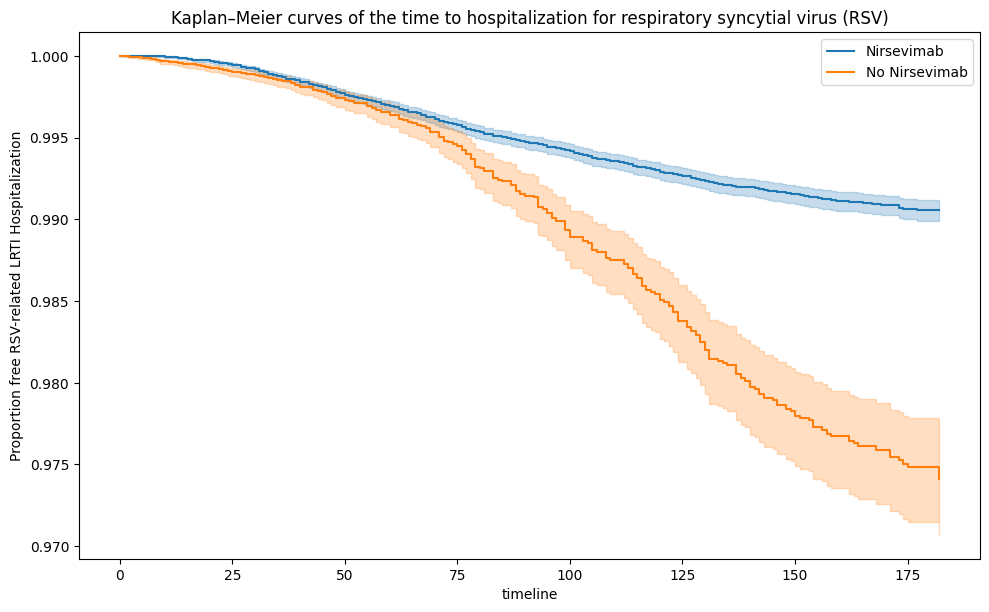

In [202]:
covs = ['start', 'inmunizado', 'stop', 'RUN', 'sexo','region','mes_nac_name','SEMANAS','event_vrs','semana_nac']
df_cox = df_cox_vrs_24.copy()
ctv_0 = CoxTimeVaryingFitter()
strata = ['region','mes_nac_name','SEMANAS','semana_nac']  
ctv_0.fit(df_cox[covs], id_col="RUN", event_col='event_vrs', start_col="start", stop_col="stop",strata=strata)
display(printSummary(ctv_0))
df_mayer_vrs_agg_24, df_mayer_vrs_24 = plot_extended_kaplan_meier(df_cox_vrs_24)

In [203]:
base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_24.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_nn_max_dist_weigths(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:2",
    max_distance=5.0
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

1:2 ['1', '2']
here aaa
Total cases = 8494, Total controls = 144839
Total cases matched is : 7566, Total control matched is : 15132
ratio: 1:2
No matched : 928
Iteration 1: norm_delta = 7.74e-01, step_size = 0.9500, log_lik = -398.27301, newton_decrement = 1.00e+02, seconds_since_start = 5.8
Iteration 2: norm_delta = 2.94e-02, step_size = 0.9500, log_lik = -302.11018, newton_decrement = 1.24e-01, seconds_since_start = 12.7
Iteration 3: norm_delta = 1.88e-03, step_size = 0.9500, log_lik = -301.98534, newton_decrement = 4.98e-04, seconds_since_start = 19.5
Iteration 4: norm_delta = 1.01e-04, step_size = 1.0000, log_lik = -301.98484, newton_decrement = 1.29e-06, seconds_since_start = 25.8
Iteration 5: norm_delta = 4.79e-09, step_size = 1.0000, log_lik = -301.98484, newton_decrement = 2.90e-15, seconds_since_start = 32.2
Convergence completed after 5 iterations.


,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.636322,0.805305,0.127815,-1.886835,-1.38581,0.749879,0.848449,0.0


this functions yields a plot KM and return 2 bbdd: df_mayer_vrs_agg, df_mayer_vrs


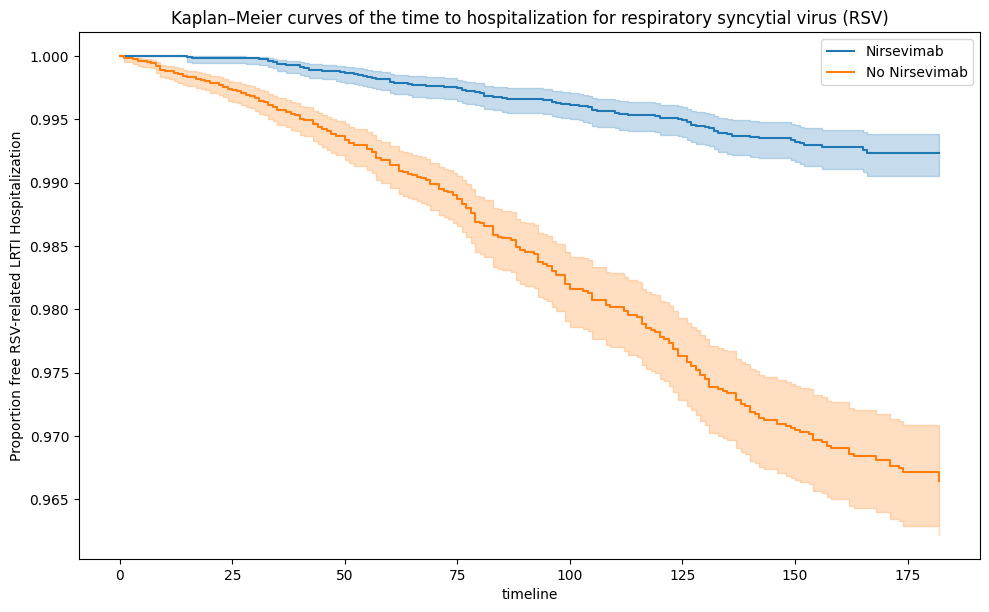

In [41]:
df_mayer_vrs_match, df_mayer_vrs_match = plot_extended_kaplan_meier(df_tv_matched)

In [7]:
from matching_case_control import match_ps_max_dist_weights

base_covs = ["sexo","SEMANAS","region",'mes_nac_name','semana_nac']  # ejemplo

df_tv = df_cox_vrs_24.copy()

df_base = (
    df_tv.sort_values(['RUN', "start"])
         .groupby('RUN', as_index=False)
         .first()[['RUN'] + base_covs]
)

ever = df_tv.groupby('RUN')['inmunizado'].max().rename("ever_imm").reset_index()
df_base = df_base.merge(ever, on='RUN', how="left").fillna({"ever_imm": 0})
df_base["ever_imm"] = df_base["ever_imm"].astype(int)

df_cases   = df_base.query("ever_imm == 0").copy()   # no inmunes
df_control = df_base.query("ever_imm == 1").copy() 

match_vars_nn     = ['semana_nac','SEMANAS']
match_vars_exact  = ["sexo", "region",'mes_nac_name']

matched_base, unmatched, matched_controls, cases, controls, ratio, n_ctrl, n_case = match_ps_max_dist_weights(
    df_control=df_control,
    df_case=df_cases,
    match_vars_nn=match_vars_nn,
    match_vars_exact=match_vars_exact,
    ratio="1:3",
    max_distance=0.02
)

match_map = matched_base[["RUN", "Group"]].drop_duplicates()
df_tv_matched = df_tv.merge(match_map, on="RUN", how="inner").copy()

ctv = CoxTimeVaryingFitter()

ctv.fit(
    df_tv_matched[["RUN", "start", "stop", "event_vrs", "Group", "inmunizado"]],
    id_col="RUN",
    start_col="start",
    stop_col="stop",
    event_col="event_vrs",
    strata=["Group"],
    show_progress=True
)

display(printSummary(ctv))

[PS MATCH] ratio=1:3  (case:control = 1:3)
[PS MATCH] Total cases    = 9205
[PS MATCH] Total controls = 144841
[PS MATCH] PS summary - cases:
count    9205.000000
mean        0.935321
std         0.018110
min         0.896205
5%          0.910175
50%         0.929102
95%         0.961913
max         0.976416
[PS MATCH] PS summary - controls:
count    144841.000000
mean          0.940558
std           0.015916
min           0.896205
5%            0.912615
50%           0.943025
95%           0.961913
max           0.979598
[PS MATCH] Matched cases (unique RUN)   = 9138
[PS MATCH] Matched controls (rows)      = 27414
[PS MATCH] Unmatched primary units      = 67
Iteration 1: norm_delta = 9.27e-01, step_size = 0.9500, log_lik = -648.96921, newton_decrement = 1.65e+02, seconds_since_start = 5.5
Iteration 2: norm_delta = 6.42e-02, step_size = 0.9500, log_lik = -502.83716, newton_decrement = 7.83e-01, seconds_since_start = 11.5
Iteration 3: norm_delta = 1.59e-03, step_size = 0.9500, log_lik =

,coef,effectiveness,se(coef),coef lower 95%,coef upper 95%,eff_lower_95,eff_upper_95,p
covariate,,,,,,,,
inmunizado,-1.733749,0.823379,0.105983,-1.941473,-1.526026,0.782602,0.856508,0.0


Covariables basales (pre): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'eleg_2024', 'categori_macro', 'percent_poor']
Covariables basales (post): ['sexo', 'region', 'Macrozona2', 'PREVI', 'SEMANAS', 'mes_nac_name', 'is_rural', 'eleg_2024', 'categori_macro', 'percent_poor']
(153333, 12) (22698, 12)


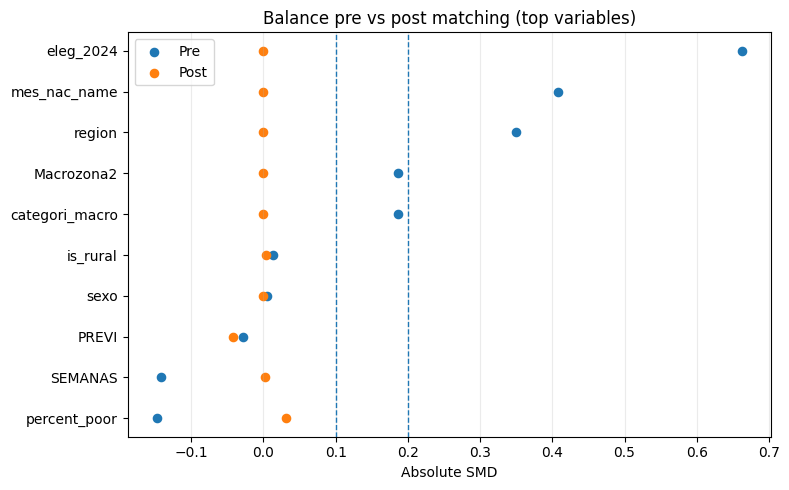

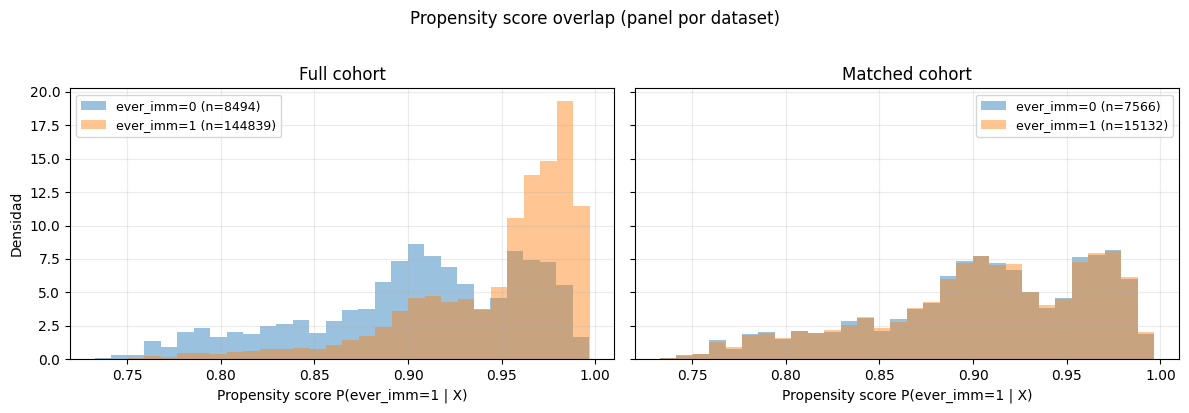

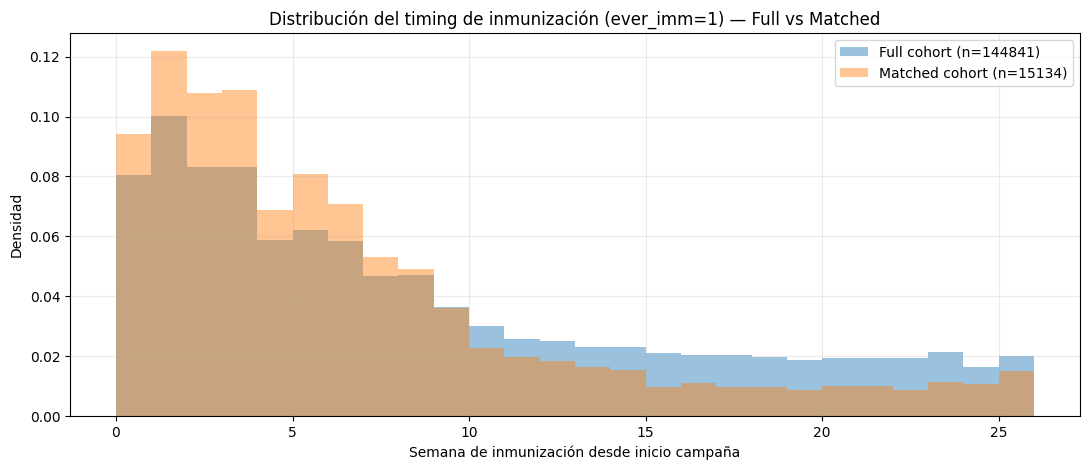

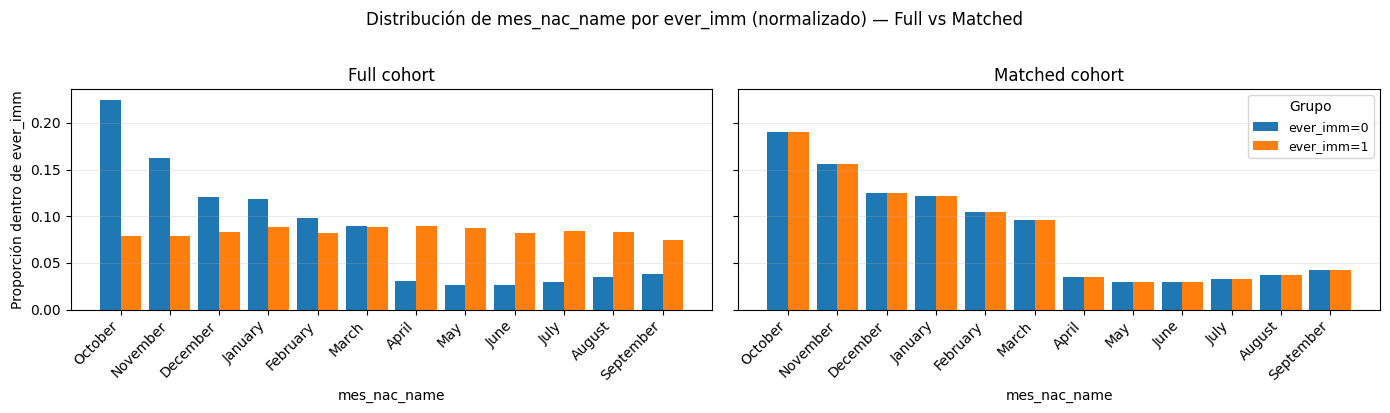

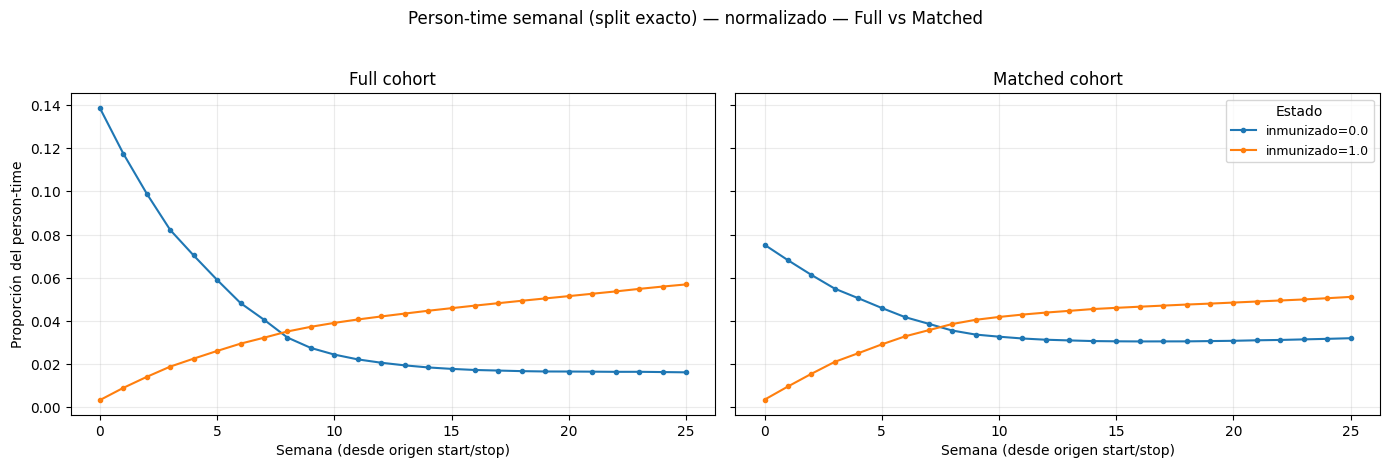

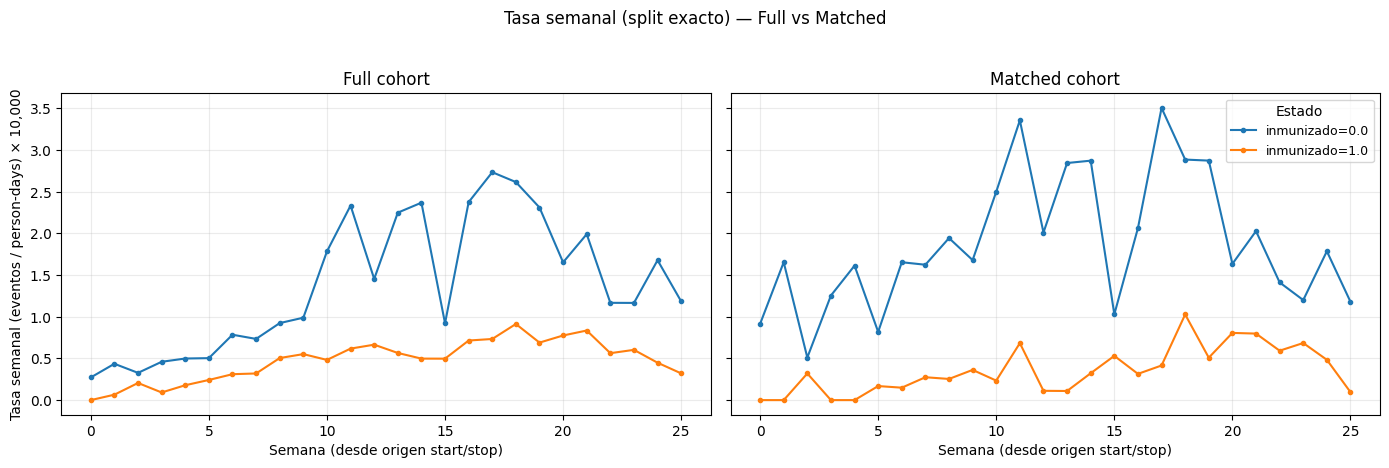

In [190]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ---------------------------
# Helpers básicos
# ---------------------------
ID = "RUN"
START = "start"
STOP = "stop"
EVENT = "event_vrs"
IMM_TV = "inmunizado"   # time-varying 0/1
MATCH_GROUP = "Group"   # solo en df_tv_matched


candidate_covs = [
    "sexo", "region", "Macrozona2", "PREVI", "SEMANAS", "mes_nac_name",
    "is_rural", "eleg_2024", "categori_macro", "categoric_regions", "percent_poor", "percent_rural"
]

# Filtramos solo las que existen en tu df
base_covs_pre = [c for c in candidate_covs if c in df_cox_vrs_24.columns]
base_covs_post = [c for c in candidate_covs if c in df_tv_matched.columns]

print("Covariables basales (pre):", base_covs_pre)
print("Covariables basales (post):", base_covs_post)

# Baseline pre y post
df_base_pre = make_baseline(df_cox_vrs_24, keep_cols=[ID] + base_covs_pre)
df_base_post = make_baseline(df_tv_matched, keep_cols=[ID] + base_covs_post)

print(df_base_pre.shape, df_base_post.shape)

smd_pre = compute_smd_table(df_base_pre, base_covs_pre)
smd_post = compute_smd_table(df_base_post, base_covs_post)

# Combinar en una tabla bonita
smd = (smd_pre.rename(columns={"SMD":"SMD_pre"})
              .merge(smd_post.rename(columns={"SMD":"SMD_post"})[["variable","SMD_post"]],
                     on="variable", how="outer")
              .sort_values(["SMD_pre","SMD_post"], ascending=False))

love_plot(smd, top=25)

# plot_ps_overlap(df_base_pre, df_base_post)

COVS_NUM = ["SEMANAS"]
COVS_CAT = ["mes_nac_name", "region", "sexo"]

origin = pd.Timestamp("2024-04-01")  # inicio campaña (ajusta si corresponde)

# Full baseline (desde tu df time-varying full + df basal por RUN)
base_full = make_baseline_df(df_cox_vrs_24, df_base=df_f_vrs_24)

# Matched baseline (desde tu df time-varying matched + df basal por RUN)
base_matched = make_baseline_df(df_tv_matched, df_base=df_f_vrs_24)



# Ajustar PS en FULL (recomendado) y aplicar el MISMO modelo a matched?
# Aquí, por simplicidad y consistencia, ajustamos por separado y comparamos distribuciones.
# Si quieres “misma escala exacta”, dime y lo dejamos entrenado en full y predicho en matched.

def fit_ps_and_score(df, y_col="ever_imm"):
    """
    Ajusta LogisticRegression para P(ever_imm=1 | X) con OHE para categóricas.
    Devuelve df con columna ps.
    """
    X = df[COVS_NUM + COVS_CAT].copy()
    y = df[y_col].astype(int)

    # pipeline: OHE para cat, passthrough num
    pre = ColumnTransformer(
        transformers=[
            ("num", "passthrough", COVS_NUM),
            ("cat", OneHotEncoder(handle_unknown="ignore"), COVS_CAT),
        ]
    )

    model = LogisticRegression(max_iter=5000, n_jobs=-1, solver="lbfgs")

    pipe = Pipeline(steps=[("pre", pre), ("lr", model)])
    pipe.fit(X, y)

    ps = pipe.predict_proba(X)[:, 1]
    out = df.copy()
    out["ps"] = ps
    return out


# ps_full = fit_ps_and_score(base_full)
# ps_matched = fit_ps_and_score(base_matched)

# plot_ps_overlap(ps_full, ps_matched)

def fit_ps_and_score(df_base, covs, treat_col="ever_imm"):
    X_num = df_base[[c for c in covs if pd.api.types.is_numeric_dtype(df_base[c])]].copy()
    X_cat_cols = [c for c in covs if c not in X_num.columns]

    # one-hot en categóricas (fit en este df)
    if X_cat_cols:
        enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        X_cat = enc.fit_transform(df_base[X_cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(X_cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        enc = None
        X = X_num.fillna(0)

    y = df_base[treat_col].astype(int).values

    model = LogisticRegression(max_iter=2000, solver="lbfgs")
    model.fit(X, y)
    ps = model.predict_proba(X)[:, 1]
    return model, enc, X_num.columns.tolist(), X_cat_cols, ps

def score_ps(df_base, covs, model, enc, num_cols, cat_cols):
    X_num = df_base[num_cols].copy() if num_cols else pd.DataFrame(index=df_base.index)
    if cat_cols:
        X_cat = enc.transform(df_base[cat_cols].astype(str))
        cat_names = enc.get_feature_names_out(cat_cols)
        X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
        X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
    else:
        X = X_num.fillna(0)

    return model.predict_proba(X)[:, 1]

# Fit PS en full (pre)
ps_covs = base_covs_pre  # puedes ajustar
ps_model, ps_enc, num_cols, cat_cols, ps_pre = fit_ps_and_score(df_base_pre, ps_covs)

df_base_pre = df_base_pre.copy()
df_base_post = df_base_post.copy()
df_base_pre["ps"] = ps_pre
df_base_post["ps"] = score_ps(df_base_post, ps_covs, ps_model, ps_enc, num_cols, cat_cols)

def plot_ps_overlap_2panels(df_pre, df_post, treat_col="ever_imm", bins=30):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

    def _panel(ax, df_, title):
        for tval in [0, 1]:
            sub = df_.loc[df_[treat_col] == tval, "ps"].dropna()
            ax.hist(sub, bins=bins, density=True, alpha=0.45,
                    label=f"ever_imm={tval} (n={len(sub)})")
        ax.set_title(title)
        ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    _panel(axes[0], df_pre,  "Full cohort")
    _panel(axes[1], df_post, "Matched cohort")

    axes[0].set_ylabel("Densidad")
    fig.suptitle("Propensity score overlap (panel por dataset)", y=1.02)
    plt.tight_layout()
    plt.show()

plot_ps_overlap_2panels(df_base_pre, df_base_post, treat_col="ever_imm", bins=30)


def plot_week_inm_distribution(base_full, base_matched, week_max=None):
    # solo inmunizados
    a = base_full.query("ever_imm==1").copy()
    b = base_matched.query("ever_imm==1").copy()

    a = a.dropna(subset=["week_inm"])
    b = b.dropna(subset=["week_inm"])

    if week_max is not None:
        a = a[a["week_inm"] <= week_max]
        b = b[b["week_inm"] <= week_max]

    fig, ax = plt.subplots(figsize=(11, 4.8))
    bins = np.arange(0, int(max(a["week_inm"].max(), b["week_inm"].max()) + 2))

    ax.hist(a["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Full cohort (n={len(a)})")
    ax.hist(b["week_inm"], bins=bins, density=True, alpha=0.45, label=f"Matched cohort (n={len(b)})")

    ax.set_xlabel("Semana de inmunización desde inicio campaña")
    ax.set_ylabel("Densidad")
    ax.set_title("Distribución del timing de inmunización (ever_imm=1) — Full vs Matched")
    ax.grid(alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_week_inm_distribution(base_full, base_matched, week_max=26)


ID="RUN"; START="start"; STOP="stop"; IMM_TV="inmunizado"


# Orden "bonito" (ajústalo a tu contexto, si tu temporada empieza Mar)
mes_order = [
    "October","November","December","January","February",
    "March","April","May","June","July","August","September"
]
pt_pre, ev_pre = weekly_person_time_and_events(df_cox_vrs_24, "Full cohort")
pt_post, ev_post = weekly_person_time_and_events(df_tv_matched, "Matched cohort")

pt_all = pd.concat([pt_pre, pt_post], ignore_index=True)
ev_all = pd.concat([ev_pre, ev_post], ignore_index=True)

# Incidence rate por 10,000 person-days (para comparar)
df_ir = (pt_all.merge(ev_all, on=["dataset","week_mid", IMM_TV], how="left")
              .fillna({"events":0})
              .assign(rate_per_10k=lambda x: 10000 * x["events"] / x["person_days"].replace(0, np.nan)))

def month_dist(df_base, label, month_col="mes_nac_name", treat_col="ever_imm"):
    d = df_base[[month_col, treat_col]].copy()
    d[month_col] = pd.Categorical(d[month_col], categories=mes_order, ordered=True)

    tab = (
        d.groupby([treat_col, month_col], dropna=False)
         .size()
         .reset_index(name="n")
    )
    tab["prop"] = tab.groupby(treat_col)["n"].transform(lambda x: x / x.sum())
    tab["dataset"] = label
    return tab

m_pre  = month_dist(df_base_pre,  "Full cohort")
m_post = month_dist(df_base_post, "Matched cohort")
m_all = pd.concat([m_pre, m_post], ignore_index=True)

# Plot: 2 paneles (Full vs Matched) y barras por ever_imm
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, ds in zip(axes, ["Full cohort", "Matched cohort"]):
    sub = m_all[m_all["dataset"] == ds].copy()
    # pivot para tener columnas 0/1 (ever_imm)
    pv = sub.pivot_table(index="mes_nac_name", columns="ever_imm", values="prop", fill_value=0).reindex(mes_order)
    x = np.arange(len(pv.index))
    w = 0.42

    ax.bar(x - w/2, pv.get(0, pd.Series(0, index=pv.index)), width=w, label="ever_imm=0")
    ax.bar(x + w/2, pv.get(1, pd.Series(0, index=pv.index)), width=w, label="ever_imm=1")

    ax.set_title(ds)
    ax.set_xticks(x)
    ax.set_xticklabels(pv.index, rotation=45, ha="right")
    ax.grid(alpha=0.25, axis="y")
    ax.set_xlabel("mes_nac_name")

axes[0].set_ylabel("Proporción dentro de ever_imm")
axes[1].legend(title="Grupo", fontsize=9)
fig.suptitle("Distribución de mes_nac_name por ever_imm (normalizado) — Full vs Matched", y=1.02)
plt.tight_layout()
plt.show()

IMM   = "inmunizado"

EPS = 1e-9  # para manejar bien intervalos [start, stop)



dfw_full    = split_intervals_to_weeks(df_cox_vrs_24, event_col=EVENT)
dfw_matched = split_intervals_to_weeks(df_tv_matched,     event_col=EVENT)

agg_full    = weekly_aggregate(dfw_full,    event_week_col="event_week")
agg_matched = weekly_aggregate(dfw_matched, event_week_col="event_week")

plot_pt_prop_full_vs_matched(agg_full, agg_matched)

plot_rate_full_vs_matched(agg_full, agg_matched)


In [ ]:
#################################################################################### si arriba tira error descomentar y correr esto 

# def fit_ps_and_score(df_base, covs, treat_col="ever_imm"):
#     X_num = df_base[[c for c in covs if pd.api.types.is_numeric_dtype(df_base[c])]].copy()
#     X_cat_cols = [c for c in covs if c not in X_num.columns]

#     # one-hot en categóricas (fit en este df)
#     if X_cat_cols:
#         enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
#         X_cat = enc.fit_transform(df_base[X_cat_cols].astype(str))
#         cat_names = enc.get_feature_names_out(X_cat_cols)
#         X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
#         X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
#     else:
#         enc = None
#         X = X_num.fillna(0)

#     y = df_base[treat_col].astype(int).values

#     model = LogisticRegression(max_iter=2000, solver="lbfgs")
#     model.fit(X, y)
#     ps = model.predict_proba(X)[:, 1]
#     return model, enc, X_num.columns.tolist(), X_cat_cols, ps

# def score_ps(df_base, covs, model, enc, num_cols, cat_cols):
#     X_num = df_base[num_cols].copy() if num_cols else pd.DataFrame(index=df_base.index)
#     if cat_cols:
#         X_cat = enc.transform(df_base[cat_cols].astype(str))
#         cat_names = enc.get_feature_names_out(cat_cols)
#         X_cat = pd.DataFrame(X_cat, columns=cat_names, index=df_base.index)
#         X = pd.concat([X_num.reset_index(drop=True), X_cat.reset_index(drop=True)], axis=1).fillna(0)
#     else:
#         X = X_num.fillna(0)

#     return model.predict_proba(X)[:, 1]

# # Fit PS en full (pre)
# ps_covs = base_covs_pre  # puedes ajustar
# ps_model, ps_enc, num_cols, cat_cols, ps_pre = fit_ps_and_score(df_base_pre, ps_covs)

# df_base_pre = df_base_pre.copy()
# df_base_post = df_base_post.copy()
# df_base_pre["ps"] = ps_pre
# df_base_post["ps"] = score_ps(df_base_post, ps_covs, ps_model, ps_enc, num_cols, cat_cols)

# # def plot_ps_overlap(df_pre, df_post, treat_col="ever_imm", bins=30):
# #     fig, ax = plt.subplots(figsize=(10, 4))

# #     for df_, label in [(df_pre,"Full cohort"), (df_post,"Matched cohort")]:
# #         for tval in [0,1]:
# #             sub = df_[df_[treat_col]==tval]["ps"].dropna()
# #             ax.hist(sub, bins=bins, density=True, alpha=0.4,
# #                     label=f"{label} | ever_imm={tval} (n={len(sub)})")

# #     ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
# #     ax.set_ylabel("Densidad")
# #     ax.set_title("Propensity score overlap (Full vs Matched)")
# #     ax.grid(alpha=0.25)
# #     ax.legend(ncol=2, fontsize=9)
# #     plt.tight_layout()
# #     plt.show()

# # plot_ps_overlap(df_base_pre, df_base_post)

# def plot_ps_overlap_2panels(df_pre, df_post, treat_col="ever_imm", bins=30):
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

#     def _panel(ax, df_, title):
#         for tval in [0, 1]:
#             sub = df_.loc[df_[treat_col] == tval, "ps"].dropna()
#             ax.hist(sub, bins=bins, density=True, alpha=0.45,
#                     label=f"ever_imm={tval} (n={len(sub)})")
#         ax.set_title(title)
#         ax.set_xlabel("Propensity score P(ever_imm=1 | X)")
#         ax.grid(alpha=0.25)
#         ax.legend(fontsize=9)

#     _panel(axes[0], df_pre,  "Full cohort")
#     _panel(axes[1], df_post, "Matched cohort")

#     axes[0].set_ylabel("Densidad")
#     fig.suptitle("Propensity score overlap (panel por dataset)", y=1.02)
#     plt.tight_layout()
#     plt.show()

# plot_ps_overlap_2panels(df_base_pre, df_base_post, treat_col="ever_imm", bins=30)

In [ ]:
counts = (
    df_f_vrs_24
    .groupby(['eleg_2024', 'event_vrs', 'inmunizado'])['RUN']
    .nunique()
)

wide = counts.unstack(['event_vrs', 'inmunizado']).fillna(0)

risk_no = (wide[(1,0)] / (wide[(0,0)] + wide[(1,0)]))*100
risk_im = (wide[(1,1)] / (wide[(0,1)] + wide[(1,1)]))*100

# 4) Armar tabla final: filas eleg, columnas risk_no_immune, risk_immune, overall(RR)
out = pd.DataFrame({
    "risk_no_immune": risk_no.round(2),
    "risk_immune": risk_im.round(2),
    "RR": (100*np.where(risk_no > 0, risk_im / risk_no, np.nan)).round(2)  # RR
})

# (Opcional) ordenar filas si quieres un orden específico
out = out.reindex(["CATCH_UP", "SEASONAL"]).dropna(how="all")

out_24 = out.copy()


counts = (
    df_f_vrs_mrz_ag
    .groupby(['eleg_2025', 'event_vrs', 'inmunizado'])['RUN']
    .nunique()
)

wide = counts.unstack(['event_vrs', 'inmunizado']).fillna(0)

risk_no = (wide[(1,0)] / (wide[(0,0)] + wide[(1,0)]))*100
risk_im = (wide[(1,1)] / (wide[(0,1)] + wide[(1,1)]))*100

# 4) Armar tabla final: filas eleg, columnas risk_no_immune, risk_immune, overall(RR)
out = pd.DataFrame({
    "risk_no_immune": risk_no.round(2),
    "risk_immune": risk_im.round(2),
    "RR": (100* risk_im / risk_no).round(2)  # RR
})

# (Opcional) ordenar filas si quieres un orden específico
out = out.reindex(["CATCH_UP", "SEASONAL"]).dropna(how="all")

out_25 = out.copy()

In [196]:
out_24

,risk_no_immune,risk_immune,RR
eleg_2024,,,
CATCH_UP,4.35,0.57,13.18
SEASONAL,1.71,0.77,44.78


In [197]:
out_25

,risk_no_immune,risk_immune,RR
eleg_2025,,,
CATCH_UP,5.76,0.88,15.22
SEASONAL,2.18,1.07,48.81


In [198]:
tab = (
    df_f_vrs_mrz_ag
    .groupby(["inmunizado", "event_vrs"])["RUN"]
    .nunique()
    .unstack(fill_value=0)
)

# asegurar columnas 0 y 1 aunque falten
tab = tab.reindex(columns=[0, 1], fill_value=0)

# total y riesgo
tab["total"] = tab[0] + tab[1]
tab["risk"] = tab[1] / tab["total"]
tab["risk_pct"] = 100 * tab["risk"]

# (opcional) dejarlo bonito
out = tab.rename(columns={0: "no_event", 1: "event"}).copy()
out["risk_pct"] = out["risk_pct"].map(lambda x: f"{x:.2f}%")

out

event_vrs,no_event,event,total,risk,risk_pct
inmunizado,,,,,
0,2945,140,3085,0.045381,4.54%
1,110865,1111,111976,0.009922,0.99%


In [199]:
tab = (
    df_f_vrs_24
    .groupby(["inmunizado", "event_vrs"])["RUN"]
    .nunique()
    .unstack(fill_value=0)
)

# asegurar columnas 0 y 1 aunque falten
tab = tab.reindex(columns=[0, 1], fill_value=0)

# total y riesgo
tab["total"] = tab[0] + tab[1]
tab["risk"] = tab[1] / tab["total"]
tab["risk_pct"] = 100 * tab["risk"]

# (opcional) dejarlo bonito
out = tab.rename(columns={0: "no_event", 1: "event"}).copy()
out["risk_pct"] = out["risk_pct"].map(lambda x: f"{x:.2f}%")

out

event_vrs,no_event,event,total,risk,risk_pct
inmunizado,,,,,
0,8164,328,8492,0.038625,3.86%
1,143870,971,144841,0.006704,0.67%
